# Валидационный отчёт: качество прогноза показателей ДТ

**Критерий 2 ТЗ «Нефтекод» — «Качество прогноза: адекватность оценки показателей качества и риска выхода за спецификацию».**

## Тезис

> Оценка качества дизельного топлива, которую агенты подают в арбитраж, воспроизводима на отложенном периоде и ошибается **предсказуемо** — в границах заявленной σ.

Отчёт проверяет этот тезис и там, где он не выполняется, называет причину.

## Два слоя валидации

Система оценивает качество в два этапа, и мерить их надо раздельно:

| Слой | Что это | Код |
|---|---|---|
| **L1** | 17 статических формул ВАК от организаторов. Без памяти, без времени. | `src.twin.vak.VakCalculator` |
| **L2** | Оценка агента: якорь ПАК/модель + байесова калибровка по ЛИМС + рост σ со временем. | `src.agents.estimation.StateEstimator` |

Ноутбук **импортирует боевой код**, а не переписывает формулы: валидируется ровно та система, которая идёт на защиту (требование ТЗ — «целостный работающий прототип, а не набор несвязанных ноутбуков»).

## Методика

| Параметр | Значение | Обоснование |
|---|---|---|
| Объект замера | **Nowcast** | Оценка агента в момент отбора пробы, до того как проба стала доступна |
| Train | 2023-01-01 … 2025-06-30 | Совпадает со сплитом `scripts/calibrate_twin.py` |
| **Out-of-Time** | **2025-07-01 … 2026-08-07** | Граница архива SCADA. ТЗ окна не задаёт, требует лишь разделения по времени |
| Лаг лаборатории | `available_at = sampled_at + 24 ч` | Медианный возраст калибровки в `quality_uncertainty.json`; чувствительность проверяется на 4/12/24 ч |
| Перемешивание | **запрещено** | ТЗ: «случайное перемешивание строк при train/test split для временных рядов не допускается» |

## Как запустить

```bash
python -m venv .venv
.venv/Scripts/pip install -r requirements-nb.txt -r requirements.txt
.venv/Scripts/python -m ipykernel install --user --name neftekod --display-name "Python 3 (neftekod .venv)"
.venv/Scripts/python -m jupyter nbconvert --to notebook --execute notebooks/01_model_evaluation.ipynb --inplace --ExecutePreprocessor.timeout=1800
```

Путь к архиву задаётся переменной окружения `NEFTEKOD_DATA_DIR` (по умолчанию `C:\хакатон данные\data`).

## Содержание

1. Данные, провенанс и допущения
2. Слой L1 — 17 формул ВАК как есть
3. Слой L2 — оценка агентов (nowcast)
4. Кинетика гидродесульфуризации
5. Колонна стабилизации К-201
6. Остатки, σ и доверительные интервалы
7. Устойчивость к выбросам ЛИМС
8. Выводы

In [1]:
import json
import math
import os
import sys
import time
import warnings
import zipfile
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

# --- пути ----------------------------------------------------------------
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
DATA_DIR = Path(os.getenv("NEFTEKOD_DATA_DIR", r"C:\хакатон данные\data"))
INITIAL = ROOT / "initial_data"
CACHE = ROOT / "data" / "processed" / "cache"
FIGDIR = ROOT / "data" / "processed" / "figures"
CACHE.mkdir(parents=True, exist_ok=True)
FIGDIR.mkdir(parents=True, exist_ok=True)

for p, what in ((DATA_DIR / "242000_tags.csv", "телеметрия 24-2000"),
                (DATA_DIR / "avt_tags.csv", "телеметрия АВТ-6"),
                (INITIAL / "ЛИМСы 01.01.2023 - н.в_ (2).xlsx", "архив ЛИМС")):
    if not p.exists():
        raise FileNotFoundError(f"Не найден {what}: {p}\\nЗадайте NEFTEKOD_DATA_DIR или положите файл на место.")

# --- окна и константы методики -------------------------------------------
TRAIN_END = pd.Timestamp("2025-07-01")     # Train: < TRAIN_END
OOT_END = pd.Timestamp("2026-08-08")       # OOT:  [TRAIN_END, OOT_END)
LIMS_LAG_H = 24.0                          # лаг лаборатории (допущение)
ASOF_TOL = pd.Timedelta("30min")           # допуск сопоставления такта и пробы
RHO_FEED = 0.847                           # т/м3, плотность сырья ГО
Q20_TO_LIMS = 1.0 / 0.878                  # пересчёт поточной серы сырья в базис ЛИМС
SPEC_S_PPM = 10.0                          # ГОСТ 32511-2013: сера <= 10 мг/кг
Q20_PLAUSIBLE_PPM = (1500.0, 13000.0)      # правдоподобная сера сырья ГО (базис ЛИМС), см. §3.1
                                           # ЛИМС сырья за 3.6 года: 2025 … 10 627 ppm, границы с запасом
Q21_PLAUSIBLE_PPM = (0.5, 100.0)           # правдоподобное показание поточного анализатора продукта
                                           # ЛИМС гидрогенизата: минимум 0.1, но 0.05 на пуске — отказ
SPEC_FLASH_C = 55.0                        # ГОСТ 32511-2013: вспышка >= 55 °C
RNG = np.random.default_rng(20260921)      # бутстрап

# --- палитра (валидирована на CVD, светлый фон) ---------------------------
C_MODEL, C_AGENT, C_LAB = "#2a78d6", "#eb6834", "#1baf7a"
C_BAD, C_MUTED, C_INK = "#e34948", "#9a9a94", "#22221f"

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": C_MUTED, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": "#e6e6e1", "grid.linewidth": 0.7,
    "axes.axisbelow": True,   # сетка под марками, а не поверх них
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.fontsize": 8.5,
    "legend.frameon": False, "lines.linewidth": 1.6, "font.size": 9.5,
    "text.color": C_INK, "axes.labelcolor": C_INK,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
})
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

print("Python      :", sys.version.split()[0])
print("numpy/pandas:", np.__version__, "/", pd.__version__)
print("Архив       :", DATA_DIR)
print("Окна        : Train < %s  |  OOT [%s .. %s)" % (
    TRAIN_END.date(), TRAIN_END.date(), OOT_END.date()))

Python      : 3.10.9
numpy/pandas: 1.26.4 / 2.3.3
Архив       : C:\хакатон данные\data
Окна        : Train < 2025-07-01  |  OOT [2025-07-01 .. 2026-08-08)


---

# 1. Данные, провенанс и допущения

*Критерий 1 ТЗ — «Работа с данными: корректная синхронизация, отсутствие временной утечки, обработка пропусков/аномалий, прозрачность единиц и признаков».*

## 1.1. Провенанс исходных файлов

Метаданные Office показывают, кто и когда создал каждый файл пакета. Это важно: файлы формул существуют в **двух версиях**, и надо доказуемо выбрать одну.

In [2]:
def office_meta(path: Path) -> dict:
    """Читает docProps/core.xml из xlsx/docx без внешних зависимостей."""
    try:
        with zipfile.ZipFile(path) as z:
            x = z.read("docProps/core.xml").decode("utf-8", "replace")
    except Exception:
        return {"файл": path.name, "создатель": "—", "изменил": "—", "создан": "—"}
    ns = {"dc": "http://purl.org/dc/elements/1.1/",
          "cp": "http://schemas.openxmlformats.org/package/2006/metadata/core-properties",
          "dcterms": "http://purl.org/dc/terms/"}
    root = ET.fromstring(x)
    def g(tag):
        el = root.find(tag, ns)
        return el.text if el is not None and el.text else "—"
    return {"файл": path.name,
            "создатель": g("dc:creator"),
            "изменил": g("cp:lastModifiedBy"),
            "создан": g("dcterms:created")[:10]}


PROV_FILES = [
    INITIAL / "ТЗ_нефтекод.docx",
    INITIAL / "ЛИМСы 01.01.2023 - н.в_ (2).xlsx",
    INITIAL / "Выгрузка ПАК 01.01.2023 - н.в_.xlsx",
    INITIAL / "Теги_хакатон.xlsx",
    INITIAL / "формулы_ВАК.xlsx",
]
prov = pd.DataFrame([office_meta(p) for p in PROV_FILES if p.exists()])
display(prov)

,файл,создатель,изменил,создан
0,ТЗ_нефтекод.docx,Организаторы хакатона,Пампура Виталий Михайлович,2026-08-13
1,ЛИМСы 01.01.2023 - н.в_ (2).xlsx,Недоливко Владимир Владимирович,Шишкин Александр Викторович,2026-08-10
2,Выгрузка ПАК 01.01.2023 - н.в_.xlsx,Недоливко Владимир Владимирович,Шишкин Александр Викторович,2026-08-11
3,Теги_хакатон.xlsx,shishkin.avi@outlook.com,Шишкин Александр Викторович,2026-07-31
4,формулы_ВАК.xlsx,openpyxl,shishkin.avi@outlook.com,2026-09-14


**Чтение таблицы.** Шишкин А. В. — последний редактор всех файлов официального пакета и автор `Теги_хакатон.xlsx` (31.07.2026). Он же сохранил `формулы_ВАК.xlsx`, сгенерированный скриптом (`creator = openpyxl`) **14.09.2026** — на полтора месяца позже пакета.

**Допущение 1.** `формулы_ВАК.xlsx` принимается как более поздняя официальная редакция формул. Ниже показано, чем именно она отличается от листа «ВАК» в `Теги_хакатон.xlsx`.

## 1.2. Расхождение двух официальных источников формул

In [3]:
def read_sheet(path: Path, sheet_idx: int) -> list:
    """Строки листа xlsx как списки значений (без openpyxl-зависимости от стилей)."""
    ns = "{http://schemas.openxmlformats.org/spreadsheetml/2006/main}"
    with zipfile.ZipFile(path) as z:
        shared = []
        if "xl/sharedStrings.xml" in z.namelist():
            for si in ET.fromstring(z.read("xl/sharedStrings.xml")).iter(ns + "si"):
                shared.append("".join(t.text or "" for t in si.iter(ns + "t")))
        names = z.namelist()
        target = sorted(n for n in names if n.startswith("xl/worksheets/sheet"))[sheet_idx]
        root = ET.fromstring(z.read(target))
    def col_idx(ref):
        letters = "".join(ch for ch in ref if ch.isalpha())
        n = 0
        for ch in letters:
            n = n * 26 + (ord(ch) - 64)
        return n - 1
    rows = []
    for r in root.iter(ns + "row"):
        d = {}
        for c in r.iter(ns + "c"):
            v = c.find(ns + "v")
            if v is None:
                continue
            d[col_idx(c.get("r"))] = shared[int(v.text)] if c.get("t") == "s" else v.text
        rows.append(d)
    return rows


def norm_formula(s: str) -> str:
    """Приводит запись формулы к сравнимому виду: убирает пробелы, унифицирует знаки."""
    if not isinstance(s, str):
        return ""
    s = s.replace("\u2212", "-").replace("\u00d7", "*").replace("x", "*").replace("х", "*")
    s = s.replace(",", ".").replace(" ", "").replace("\n", "")
    return s.lower()


# Лист «ВАК» официального пакета: тройки колонок (имя, формула) по трём группам
tags_rows = read_sheet(INITIAL / "Теги_хакатон.xlsx", 1)
official = {}
for r in tags_rows[1:]:
    for c in (0, 2, 4):
        name, f = r.get(c), r.get(c + 1)
        if isinstance(name, str) and ":" in name and isinstance(f, str):
            official[name.strip()] = f.strip()

# Сентябрьский файл формул: два листа, колонки (№, Модель, Формула, Пример)
sept = {}
for sheet in (0, 1):
    for r in read_sheet(INITIAL / "формулы_ВАК.xlsx", sheet)[1:]:
        name, f = r.get(1), r.get(2)
        if isinstance(name, str) and ":" in name and isinstance(f, str):
            sept[name.strip()] = f.strip()

diff_rows = []
for name in sorted(set(official) | set(sept)):
    a, b = official.get(name, ""), sept.get(name, "")
    same = norm_formula(a) == norm_formula(b)
    diff_rows.append({"модель": name, "совпадают": "да" if same else "НЕТ",
                      "Теги_хакатон.xlsx (31.07)": a[:78], "формулы_ВАК.xlsx (14.09)": b[:78]})
diff = pd.DataFrame(diff_rows)
n_diff = int((diff["совпадают"] == "НЕТ").sum())
print(f"Формул всего: {len(diff)}   расходятся: {n_diff}")
display(diff[diff["совпадают"] == "НЕТ"][["модель", "Теги_хакатон.xlsx (31.07)", "формулы_ВАК.xlsx (14.09)"]])

Формул всего: 17   расходятся: 12


,модель,Теги_хакатон.xlsx (31.07),формулы_ВАК.xlsx (14.09)
0,24-2000:GODT:CFPP,0.22088*T6-102.375-47.75834*P8+0.03862*F9+43.6...,0.22088×T23 − 102.375 − 47.75834×P8 + 0.03862×...
1,24-2000:GODT:CloudPoint,F22+0.0021*W7+0.00008*F25-0.30656*F1+0.12018*T...,0.0002×F22 + 0.0021×W7 + 0.00008×F25 − 0.30656...
2,24-2000:GODT:D15,667.881+0.15417*LIMS:24-2000.Pipeline.D15+0.00...,667.881 + 0.15417×LIMS.D15 + 0.00005×F22 + 0.1...
5,24-2000:GODT:T50,44.625+10.0224*P13+0.06981*F9+0.8052*T6,44.625 + 10.0224×P13 + 0.06981×F9 + 0.471×T6
6,24-2000:GODT:T90,162.998+0.12945*T12+59.57*F15+0.00036*W7+T23*0...,162.998 + 0.12945×T12 + 59.57×(F15/2000) + 0.0...
7,24-2000:GODT:T95,0.03814*F9-9.201-0.00002*F2+0.62259*T6+0.48321...,0.03814×F9 − 9.201 − 0.00002×F2 + 0.50×T6 + 0....
8,AVT6:240-350:CFPP,"31,40363 - 0,06784xT33 + 17,411xP67 - 8,11544x...",31.40363 − 0.06784×T33 + 17.411×P67 − 8.11544×...
9,AVT6:240-350:D15,"791,22872 - 5,30294x(F30/(F32+ F30)) + 0,52755...",791.22872 − 5.30294×(F65/(F32+F30)) + 0.52755×...
11,AVT6:240-350:T50,283.177+F7*(-0.01685)+0.06248*F30+0.22048*F34-...,283.177 − 0.01685×F7 + 0.06248×F30 + 0.22048×F...
13,AVT6:350:CFPP,"19,27111 - 0,10582xT48 + 0,13836xT40 - 0,42304...",19.27111 − 0.10582×T48 + 0.13836×T40 − 0.42304...


**Вывод.** Часть расхождений — явные опечатки июльского файла: у `24-2000:GODT:CloudPoint` пропал коэффициент при `F22` (голый `F22 ≈ 10 500` разнёс бы формулу на четыре порядка), у `AVT6:240-350:CFPP` не закрыты скобки. Сентябрьская редакция их чинит. `VakCalculator` реализует именно её — это проверяется в §1.6 численно.

## 1.3. Телеметрия: загрузка и аппаратный клампинг

In [4]:
HT_COLS = ["date", "F1", "F2", "W4", "T5", "T6", "W7", "P8", "F9", "W10", "T11",
           "T12", "P13", "F14", "F15", "T16", "F17", "T18", "F19", "Q20", "Q21",
           "F22", "T23", "P24", "F25", "F26"]
AVT_COLS = ["date", "P4", "T6", "F7", "T11", "T13", "T15", "T18", "T20", "F30",
            "F31", "F32", "T33", "F34", "F36", "T37", "T40", "T42", "L43", "F45",
            "T48", "P50", "P51", "P52", "F53", "T55", "F57", "T58", "F59", "T61",
            "F63", "F64", "F65", "T66", "P67"]
CLAMP_VALUES = (307.0, 313.0)
SCADA_CACHE = CACHE / "scada_raw_v1.parquet"   # кэш СЫРЫХ тегов: клампинг снимается ниже, осознанно


def load_scada(force: bool = False) -> pd.DataFrame:
    if SCADA_CACHE.exists() and not force:
        return pd.read_parquet(SCADA_CACHE)
    ht = pd.read_csv(DATA_DIR / "242000_tags.csv", usecols=HT_COLS)
    avt = pd.read_csv(DATA_DIR / "avt_tags.csv", usecols=AVT_COLS)
    ht["date"] = pd.to_datetime(ht["date"])
    avt["date"] = pd.to_datetime(avt["date"])
    ht = ht.rename(columns={c: f"HT_{c}" for c in HT_COLS if c != "date"})
    avt = avt.rename(columns={c: f"AVT_{c}" for c in AVT_COLS if c != "date"})
    df = pd.merge(ht, avt, on="date", how="inner").sort_values("date").reset_index(drop=True)
    df.to_parquet(SCADA_CACHE, index=False)
    return df


t0 = time.time()
scada_raw = load_scada()
print(f"SCADA: {len(scada_raw):,} тактов x {scada_raw.shape[1]-1} тегов за {time.time()-t0:.1f} c")
print("Период:", scada_raw['date'].min(), "—", scada_raw['date'].max())
step = scada_raw["date"].diff().mode()[0]
print("Шаг дискретизации:", step)

SCADA: 189,217 тактов x 59 тегов за 0.1 c
Период: 2023-01-01 00:00:00 — 2026-08-07 00:00:00
Шаг дискретизации: 0 days 00:10:00


### Правило `307/313 → NaN`: почему слепое применение неверно

`scripts/calibrate_twin.py` заменяет значения `307` и `313` на `NaN` **во всех тегах подряд**. Для части тегов это верно — там `307` действительно код отказа. Но для тегов вроде `AVT_T17` (рабочий диапазон до 380 °C) температура 307 °C нормальна, и слепое удаление выбрасывает валидные измерения.

**Допущение 2.** Значение признаётся кодом отказа при выполнении хотя бы одного условия:

1. оно лежит **вне робастной ограды** остального распределения тега — за пределами `[Q1 − 3·IQR; Q3 + 3·IQR]`, посчитанных по значениям без самих 307/313;
2. оно **равно максимуму тега** по всему архиву, то есть сигнал упирается в него как в потолок.

Первое условие ловит `307` у поточной серы сырья `HT_Q20`, где рабочий диапазон — тысячи ppm. Второе — случаи вроде `HT_F9`, где 307 формально попадает в размах расхода, но является жёстким потолком и никогда не превышается. Значения вроде 307 °C у `AVT_T17` при этом сохраняются как валидные.

In [5]:
num_cols = [c for c in scada_raw.columns if c != "date"]
audit = []
scada = scada_raw.copy()
removed = kept = 0
for c in num_cols:
    s = scada_raw[c]
    rest = s[~s.isin(CLAMP_VALUES)].dropna()
    if len(rest) < 100:
        continue
    q1, q3 = np.percentile(rest, [25, 75])
    lo_fence, hi_fence = q1 - 3 * (q3 - q1), q3 + 3 * (q3 - q1)
    tag_max = float(s.max())
    for v in CLAMP_VALUES:
        mask = s == v
        hits = int(mask.sum())
        if hits == 0:
            continue
        # код отказа, если значение вне робастной ограды ЛИБО упирается в потолок тега
        is_code = bool(v < lo_fence or v > hi_fence or abs(tag_max - v) < 1e-9)
        audit.append({"тег": c, "значение": v, "совпадений": hits, "доля,%": 100 * hits / len(s),
                      "рабочий диапазон (Q1…Q3)": f"{q1:,.1f} … {q3:,.1f}",
                      "трактовка": "код отказа" if is_code else "в рабочем диапазоне"})
        if is_code:
            scada.loc[mask, c] = np.nan
            removed += hits
        else:
            kept += hits

assert audit, ("В загруженной телеметрии нет значений 307/313. Похоже, кэш "
               f"{SCADA_CACHE.name} собран из уже очищенных данных — удалите его и перезапустите.")
clamp_audit = pd.DataFrame(audit).sort_values("доля,%", ascending=False).reset_index(drop=True)

print(f"Тегов затронуто: {clamp_audit['тег'].nunique()}   снято как код отказа: {removed:,}   "
      f"сохранено как валидные: {kept:,}")
print(f"Слепое правило удалило бы {removed + kept:,} значений — на {kept:,} больше "
      f"({100*kept/(removed+kept):.1f} %)")
display(clamp_audit.head(12).round(2))

Тегов затронуто: 45   снято как код отказа: 64,778   сохранено как валидные: 4,829
Слепое правило удалило бы 69,607 значений — на 4,829 больше (6.9 %)


,тег,значение,совпадений,"доля,%",рабочий диапазон (Q1…Q3),трактовка
0,HT_Q20,307.0,22043,11.65,"7,281.2 … 9,386.0",код отказа
1,HT_Q21,307.0,5618,2.97,7.5 … 9.3,код отказа
2,HT_F2,307.0,5454,2.88,"88,727.5 … 97,573.8",код отказа
3,AVT_T20,307.0,3299,1.74,113.4 … 114.4,код отказа
4,AVT_T66,307.0,2943,1.56,250.7 … 256.9,код отказа
5,HT_T16,307.0,2868,1.52,30.7 … 38.9,код отказа
6,AVT_P52,307.0,2380,1.26,-0.0 … 0.0,код отказа
7,AVT_T15,307.0,2370,1.25,132.4 … 150.8,код отказа
8,AVT_T11,307.0,2335,1.23,53.6 … 73.9,код отказа
9,HT_F17,307.0,2324,1.23,235.4 … 285.3,в рабочем диапазоне


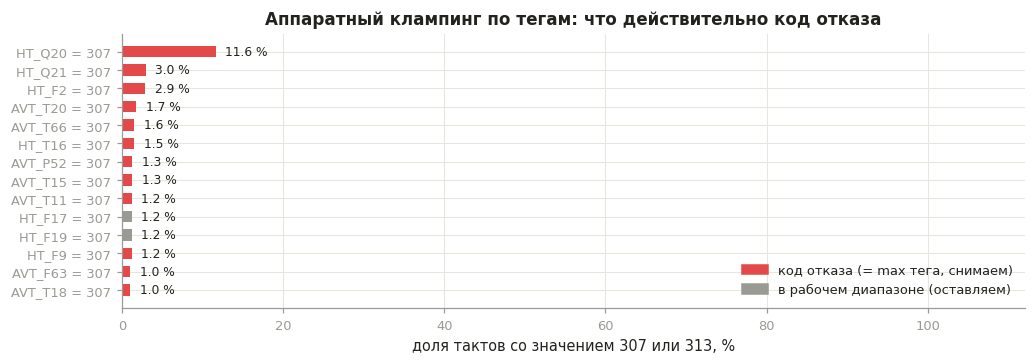

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 3.4))
top = clamp_audit.head(14).iloc[::-1]
colors = [C_BAD if t == "код отказа" else C_MUTED for t in top["трактовка"]]
ax.barh([f"{t} = {int(v)}" for t, v in zip(top["тег"], top["значение"])],
        top["доля,%"], color=colors, height=0.62)
for y, (v, t) in enumerate(zip(top["доля,%"], top["трактовка"])):
    ax.text(v + 1.2, y, f"{v:.1f} %", va="center", fontsize=8, color=C_INK)
ax.set_xlim(0, 112)
ax.set_xlabel("доля тактов со значением 307 или 313, %")
ax.set_title("Аппаратный клампинг по тегам: что действительно код отказа")
handles = [plt.Rectangle((0, 0), 1, 1, color=C_BAD), plt.Rectangle((0, 0), 1, 1, color=C_MUTED)]
ax.legend(handles, ["код отказа (= max тега, снимаем)", "в рабочем диапазоне (оставляем)"], loc="lower right")
plt.tight_layout()
plt.savefig(FIGDIR / "01_clamping.png", bbox_inches="tight")
plt.show()

`AVT_D10` (плотность нефти) забит значением `307` в 99.99 % тактов — датчик мёртв, тег непригоден для любых расчётов. `HT_Q20` — поточная сера сырья, вход кинетики ГДС — теряет 11.6 % тактов; это прямо влияет на §4.

## 1.4. Архив ЛИМС

In [7]:
LIMS_FILE = INITIAL / "ЛИМСы 01.01.2023 - н.в_ (2).xlsx"
# Границы блоков широкой таблицы -> код точки отбора (лист «ЛА» файла Теги_хакатон.xlsx)
LIMS_POINTS = {
    0:  ("AVT_P1",   "АВТ, точка 1 — ФРАКЦ_ДИЗ"),
    22: ("AVT_P2",   "АВТ, точка 2 — дизельное топливо"),
    36: ("AVT_P2_1", "АВТ, точка 2.1 — дизельное топливо"),
    50: ("AVT_P3",   "АВТ, точка 3 — дизельное топливо"),
    66: ("HT_FEED",  "Гидроочистка, точка 1 — сырьё"),
    82: ("HT_PROD",  "Гидроочистка, точка 2 — гидрогенизат"),
}
LIMS_CACHE = CACHE / "lims_long.parquet"


def load_lims(force: bool = False) -> pd.DataFrame:
    """Широкая таблица пар (дата, значение) -> длинный формат."""
    if LIMS_CACHE.exists() and not force:
        return pd.read_parquet(LIMS_CACHE)
    raw = pd.read_excel(LIMS_FILE, header=None)
    starts = sorted(LIMS_POINTS)
    frames = []
    for c in range(0, raw.shape[1], 2):
        param = raw.iat[1, c]
        if not isinstance(param, str) or not param.strip():
            continue
        unit = raw.iat[2, c]
        code_, label = LIMS_POINTS[[s for s in starts if s <= c][-1]]
        sub = raw.iloc[4:, [c, c + 1]].copy()
        sub.columns = ["sampled_at", "value"]
        sub["sampled_at"] = pd.to_datetime(sub["sampled_at"], errors="coerce")
        sub["value"] = pd.to_numeric(sub["value"], errors="coerce")
        sub = sub.dropna(subset=["sampled_at", "value"])
        sub["point"], sub["point_label"] = code_, label
        sub["param"] = param.strip()
        sub["unit"] = unit if isinstance(unit, str) else ""
        frames.append(sub)
    out = pd.concat(frames, ignore_index=True).sort_values(["point", "param", "sampled_at"])
    out = out.reset_index(drop=True)
    out.to_parquet(LIMS_CACHE, index=False)
    return out


lims = load_lims()
lims["available_at"] = lims["sampled_at"] + pd.Timedelta(hours=LIMS_LAG_H)
print(f"ЛИМС: {len(lims):,} измерений, {lims['point'].nunique()} точек отбора, "
      f"{lims['param'].nunique()} показателей")
print("Период:", lims["sampled_at"].min(), "—", lims["sampled_at"].max())
hours = lims["sampled_at"].dt.hour.value_counts().head(4)
print("Частые часы отбора:", ", ".join(f"{h}:00 — {n} проб" for h, n in hours.items()))

ЛИМС: 36,800 измерений, 6 точек отбора, 17 показателей
Период: 2023-01-01 02:00:00 — 2026-08-09 14:00:00
Частые часы отбора: 10:00 — 27187 проб, 14:00 — 4730 проб, 6:00 — 822 проб, 22:00 — 633 проб


In [8]:
cov = (lims.assign(
    окно=np.where(lims["sampled_at"] < TRAIN_END, "Train",
                  np.where(lims["sampled_at"] < OOT_END, "OOT", "вне окон")))
    .pivot_table(index=["point", "param"], columns="окно", values="value", aggfunc="size")
    .fillna(0).astype(int))
cov["всего"] = cov.sum(axis=1)
cov = cov.sort_values("всего", ascending=False)
print("Наполнение выборок по показателям (проб):")
display(cov[[c for c in ("Train", "OOT", "всего") if c in cov.columns]].head(24))

Наполнение выборок по показателям (проб):


окно                Train  OOT  всего
point   param                        
HT_PROD FlashPoint   1085  431   1518
        Mg.Sulfur     985  475   1462
AVT_P3  CloudPoint    967  426   1395
        95%.T         936  429   1367
        EBP.T         936  429   1367
        IBP.T         936  429   1367
        50%.T         936  429   1367
        90%.T         936  390   1328
HT_PROD 95%.T         900  390   1292
        IBP.T         900  389   1291
        I250          896  385   1282
        I350          895  383   1279
HT_FEED IBP.T         891  383   1276
        EBP.T         891  383   1276
        95%.T         891  383   1276
        50%.T         891  383   1276
        CloudPoint    883  371   1256
AVT_P1  PourPoint     869  384   1255
HT_PROD 50%.T         900  350   1252
        90%.T         900  350   1252
HT_FEED 90%.T         891  341   1234
HT_PROD CloudPoint    844  355   1201
        D15           839  174   1015
AVT_P1  95%.T         401  246    649

Пробы берутся **раз в сутки по маршрутному графику** — у гидроочистки и точки АВТ-3 это 10:00, у точки АВТ-1 — 14:00. Это время **отбора**, а не готовности анализа: колонки `available_at` в исходнике нет.

**Допущение 3.** `available_at = sampled_at + 24 ч`. Чувствительность к этому допущению проверяется в §6.

Разброс наполнения огромен: от 1462 проб по сере гидрогенизата до 42 по цетановому числу и 44 по ПТФ точки АВТ-1. Для редких показателей метрика подаётся с бутстрап-интервалом, а не как одно число.

## 1.5. Привязка формул ВАК к точкам отбора

Формулы ВАК разбиты на три группы, а ЛИМС — на шесть точек отбора, и прямого соответствия в выданных файлах нет. Восстановлено по технологическим схемам `initial_data/АВТ_схемы` и составу показателей:

| Группа ВАК | Поток на схеме | Точка ЛИМС | Довод |
|---|---|---|---|
| `AVT6:350:*` | «фр. до 350 °С» (`F56/F57`, схема 2, стоит анализатор QY) | **AVT_P1** | `И-350` и «температура помутнения **до 350**» есть только в этой точке |
| `AVT6:240-350:*` | дизельный погон с К-9 (`F32`), схема 3 | **AVT_P3** | Точка даёт ровно четвёрку показателей группы: T50, EBP, D15, ПТФ |
| `24-2000:GODT:*` | гидрогенизат после К-201 | **HT_PROD** | Единственная точка гидроочистки с продуктовыми показателями |

**Допущение 4.** Мэппинг выведен из схем и состава ЛИМС. Ниже он проверяется численно: для каждой формулы считается MAE против **всех** точек отбора, и выигрывать должна предсказанная.

---

# 2. Слой L1 — 17 формул ВАК как есть

Формулы даны организаторами и **не обучаются**. Задача раздела — измерить, насколько они годятся как есть, и получить точку отсчёта для слоя L2.

## 2.1. Расчёт ВАК по всему архиву

Две формулы — `24-2000:GODT:D15` и `24-2000:GODT:T95` — **авторегрессионные**: в них входит последнее лабораторное значение того же потока (`LIMS:24-2000.Pipeline.D15`, `…95%.T`). Чтобы не получить утечку из будущего, подставляется не одновременная проба, а последняя **доступная** на момент такта, то есть отобранная минимум за 24 ч до него.

In [9]:
from src.twin.vak import VakCalculator  # боевой код, а не копия формул


def attach_causal_lims(df: pd.DataFrame, lims_df: pd.DataFrame) -> pd.DataFrame:
    """Подмешивает последние ДОСТУПНЫЕ пробы ЛИМС, входящие в формулы ВАК."""
    out = df.sort_values("date").copy()
    for param, col in (("D15", "LIMS:24-2000.Pipeline.D15"),
                       ("95%.T", "LIMS:24-2000.Pipeline.95%.T")):
        src = (lims_df[(lims_df["point"] == "HT_PROD") & (lims_df["param"] == param)]
               [["available_at", "value"]].sort_values("available_at")
               .rename(columns={"value": col}))
        out = pd.merge_asof(out, src, left_on="date", right_on="available_at",
                            direction="backward").drop(columns=["available_at"])
    return out


scada_v = attach_causal_lims(scada, lims)
t0 = time.time()
recs = scada_v[[c for c in scada_v.columns if c != "date"]].to_dict("records")
vak = pd.DataFrame([VakCalculator.calculate(r) for r in recs])
vak.insert(0, "date", scada_v["date"].values)
VAK_MODELS = [c for c in vak.columns if c != "date"]
print(f"Рассчитано {len(VAK_MODELS)} формул ВАК на {len(vak):,} тактах за {time.time()-t0:.1f} c")

# Фильтр рабочих режимов. На остановах и пусках знаменатели формул вырождаются
# (например F32 + F30 -> 0 в AVT6:240-350:D15) и значения улетают на порядки.
#
# Одного расхода сырья НЕДОСТАТОЧНО: в архиве есть остановы, где F9 даёт одиночные
# всплески выше 120 т/ч, тогда как реактор холодный и разгружен (T6 около 8 °C,
# P13 около 0.015 МПа). Поэтому режим считается рабочим только при одновременном
# выполнении условий по расходу, температуре входа и давлению.
WORK = ((scada_v["HT_F9"] > 120.0) & (scada_v["AVT_F65"] > 400.0)
        & (scada_v["HT_T6"] > 300.0) & (scada_v["HT_P13"] > 3.0)).to_numpy()
vak_work = vak[WORK].reset_index(drop=True)
print(f"Рабочих тактов: {WORK.sum():,} из {len(WORK):,} "
      f"({100*WORK.mean():.1f} %) — остальное останов/пуск, формулы там не определены")
display(vak_work[VAK_MODELS].describe().T[["count", "mean", "std", "min", "max"]].round(2))

Рассчитано 17 формул ВАК на 189,217 тактах за 7.6 c
Рабочих тактов: 176,746 из 189,217 (93.4 %) — остальное останов/пуск, формулы там не определены


,count,mean,std,min,max
AVT6:240-350:D15,176746.0,848.74,134.86,-42763.41,18085.85
AVT6:240-350:T50,176746.0,278.82,4.02,255.44,340.48
AVT6:240-350:EBP,176746.0,357.98,112.60,-542.86,1203.90
AVT6:240-350:CFPP,176746.0,-5.21,12.98,-3882.00,1550.51
AVT6:350-500:ViscosityK,176746.0,3.92,0.22,2.08,12.95
AVT6:350:CFPP,176746.0,-1.11,10.72,-3316.22,1257.92
AVT6:350:T50,176746.0,315.59,8.69,221.12,649.85
AVT6:350:I350,176746.0,84.01,4.68,-26.56,166.36
AVT6:350:D15,176746.0,882.19,8.73,-1705.62,1881.49
24-2000:GODT:T90,176746.0,343.16,6.63,239.79,370.63


In [10]:
VAK_TO_LIMS = {
    "AVT6:240-350:D15":        ("AVT_P3", "D15"),
    "AVT6:240-350:T50":        ("AVT_P3", "50%.T"),
    "AVT6:240-350:EBP":        ("AVT_P3", "EBP.T"),
    "AVT6:240-350:CFPP":       ("AVT_P3", "FilterabilityLimit.T"),
    "AVT6:350:D15":            ("AVT_P1", "D15"),
    "AVT6:350:T50":            ("AVT_P1", "50%.T"),
    "AVT6:350:I350":           ("AVT_P1", "I350"),
    "AVT6:350:CFPP":           ("AVT_P1", "CFPP"),
    "AVT6:350-500:ViscosityK": (None, None),        # эталона в ЛИМС нет
    "24-2000:GODT:T90":        ("HT_PROD", "90%.T"),
    "24-2000:GODT:T50":        ("HT_PROD", "50%.T"),
    "24-2000:GODT:I250":       ("HT_PROD", "I250"),
    "24-2000:GODT:D15":        ("HT_PROD", "D15"),
    "24-2000:GODT:CloudPoint": ("HT_PROD", "CloudPoint"),
    "24-2000:GODT:CFPP":       ("HT_PROD", "CFPP"),
    "24-2000:GODT:T95":        ("HT_PROD", "95%.T"),
    "24-2000:GODT:IBP":        ("HT_PROD", "IBP.T"),
}
AUTOREGRESSIVE = {"24-2000:GODT:D15", "24-2000:GODT:T95"}
assert set(VAK_TO_LIMS) == set(VAK_MODELS), "каталог формул разошёлся с расчётом"


def pair_model_with_lab(model: str, point: str, param: str) -> pd.DataFrame:
    """Значение формулы на момент отбора пробы."""
    lab = (lims[(lims["point"] == point) & (lims["param"] == param)]
           [["sampled_at", "value"]].sort_values("sampled_at")
           .rename(columns={"value": "y_true"}))
    pred = vak_work[["date", model]].sort_values("date").rename(columns={model: "y_pred"})
    m = pd.merge_asof(lab, pred, left_on="sampled_at", right_on="date",
                      direction="nearest", tolerance=ASOF_TOL)
    m = m.dropna(subset=["y_pred", "y_true"])
    m["model"], m["point"], m["param"] = model, point, param
    return m[["model", "point", "param", "sampled_at", "y_true", "y_pred"]]


pairs = pd.concat([pair_model_with_lab(m, p, q) for m, (p, q) in VAK_TO_LIMS.items() if p],
                  ignore_index=True)
print(f"Сопоставлено пар «формула — проба»: {len(pairs):,} по {pairs['model'].nunique()} формулам")
print(f"Без эталона: AVT6:350-500:ViscosityK — вязкости нет ни в одной точке ЛИМС")

Сопоставлено пар «формула — проба»: 12,807 по 16 формулам
Без эталона: AVT6:350-500:ViscosityK — вязкости нет ни в одной точке ЛИМС


## 2.2. Проверка мэппинга точек отбора

Каждая формула сравнивается со **всеми** точками отбора, где есть её показатель. Проверка проводится только на **Train**, чтобы отложенная выборка осталась нетронутой.

In [11]:
PARAM_ALIASES = {"CFPP": ["CFPP", "FilterabilityLimit.T"], "T50": ["50%.T"], "T90": ["90%.T"],
                 "T95": ["95%.T"], "EBP": ["EBP.T"], "IBP": ["IBP.T"], "D15": ["D15"],
                 "I350": ["I350"], "I250": ["I250"], "CloudPoint": ["CloudPoint"]}
check_rows = []
for model, (exp_point, exp_param) in VAK_TO_LIMS.items():
    if exp_point is None:
        continue
    prop = model.rsplit(":", 1)[1]
    cand_params = PARAM_ALIASES.get(prop, [exp_param])
    # Установка известна из имени формулы; неизвестна только точка отбора внутри неё,
    # поэтому кандидаты ограничены точками той же установки.
    candidates = (["AVT_P1", "AVT_P2", "AVT_P2_1", "AVT_P3"] if model.startswith("AVT6")
                  else ["HT_FEED", "HT_PROD"])
    best, rec = None, {"формула": model, "ожидаемая точка": exp_point}
    for point in candidates:
        maes = []
        for param in cand_params:
            sub = lims[(lims["point"] == point) & (lims["param"] == param)]
            if len(sub) < 10:
                continue
            m = pair_model_with_lab(model, point, param)
            m = m[m["sampled_at"] < TRAIN_END]
            if len(m) >= 10:
                maes.append(float((m["y_pred"] - m["y_true"]).abs().mean()))
        if maes:
            rec[point] = min(maes)
            if best is None or min(maes) < best[1]:
                best = (point, min(maes))
    n_cand = sum(1 for p in candidates if p in rec)
    rec["лучшая точка"] = best[0] if best else "—"
    if best is None:
        rec["вердикт"] = "нет данных"
    elif exp_point not in rec:
        rec["вердикт"] = "нет данных на Train"
    elif best[0] == exp_point:
        rec["вердикт"] = "подтверждено" if n_cand > 1 else "единственный кандидат"
    elif rec[exp_point] <= best[1] * 1.25:
        # разница меньше четверти: показатель у потоков почти одинаков, MAE их не различает
        rec["вердикт"] = "неразличимо"
    else:
        rec["вердикт"] = "ПРОТИВОРЕЧИТ"
    check_rows.append(rec)

mapping_check = pd.DataFrame(check_rows)
point_cols = [c for c in ("AVT_P1", "AVT_P2", "AVT_P2_1", "AVT_P3", "HT_FEED", "HT_PROD")
              if c in mapping_check.columns]
mapping_check = mapping_check[["формула", "ожидаемая точка"] + point_cols +
                              ["лучшая точка", "вердикт"]]
verdicts = mapping_check["вердикт"].value_counts().to_dict()
print("Проверка мэппинга по MAE на Train (меньше — лучше):")
for k, v in verdicts.items():
    print(f"  {k}: {v}")
display(mapping_check.round(2))

Проверка мэппинга по MAE на Train (меньше — лучше):
  подтверждено: 9
  единственный кандидат: 4
  неразличимо: 2
  нет данных на Train: 1


,формула,ожидаемая точка,AVT_P1,AVT_P2,AVT_P2_1,AVT_P3,HT_FEED,HT_PROD,лучшая точка,вердикт
0,AVT6:240-350:D15,AVT_P3,30.89,17.38,7.90,5.94,NaN,NaN,AVT_P3,подтверждено
1,AVT6:240-350:T50,AVT_P3,36.70,27.81,28.35,3.59,NaN,NaN,AVT_P3,подтверждено
2,AVT6:240-350:EBP,AVT_P3,67.74,88.11,64.44,60.80,NaN,NaN,AVT_P3,подтверждено
3,AVT6:240-350:CFPP,AVT_P3,NaN,NaN,NaN,2.61,NaN,NaN,AVT_P3,единственный кандидат
4,AVT6:350:D15,AVT_P1,2.80,49.38,23.94,37.96,NaN,NaN,AVT_P1,подтверждено
5,AVT6:350:T50,AVT_P1,5.06,61.93,9.38,33.16,NaN,NaN,AVT_P1,подтверждено
6,AVT6:350:I350,AVT_P1,34.92,NaN,NaN,NaN,NaN,NaN,AVT_P1,единственный кандидат
7,AVT6:350:CFPP,AVT_P1,NaN,NaN,NaN,4.48,NaN,NaN,AVT_P3,нет данных на Train
8,24-2000:GODT:T90,HT_PROD,NaN,NaN,NaN,NaN,10.84,13.22,HT_FEED,неразличимо
9,24-2000:GODT:T50,HT_PROD,NaN,NaN,NaN,NaN,9.80,7.11,HT_PROD,подтверждено


**Как читать эту таблицу.** Установка в имени формулы задана явно (`AVT6:` или `24-2000:`), неизвестна только точка отбора **внутри** неё — поэтому кандидаты ограничены точками своей установки. Сравнивать формулу для дизельного погона АВТ с гидрогенизатом физически бессмысленно.

Сильнее всего разделяет **плотность**: `AVT6:350:D15` даёт MAE 2.9 против точки AVT_P1 и 24–50 против остальных точек АВТ — разница на порядок, спутать невозможно. То же у `AVT6:240-350:D15`, `24-2000:GODT:D15`, `GODT:T95`, `GODT:T50` и `AVT6:*:T50`.

Вердикт **«неразличимо»** — не ошибка мэппинга, а предел метода: `T90`, `CloudPoint`, `IBP` у сырья и продукта гидроочистки численно почти совпадают (гидроочистка меняет фракционный состав слабо), и MAE их не различает. **«Единственный кандидат»** означает, что показатель измеряется лишь в одной точке установки, и выбирать не из чего. Для `AVT6:350:CFPP` данных на Train нет вовсе — все 44 пробы ПТФ точки AVT_P1 появились только после июля 2025.

Итог: мэппинг из §1.5 подтверждается везде, где проверка способна дать ответ, и **нигде ему не противоречит**.

## 2.3. Метрики качества формул: $R^2$, MAE, RMSE

**Почему $R^2$ здесь нельзя читать в лоб.** Сера, вспышка и фракционный состав удерживаются операторами в узком коридоре — регулятор съедает почти всю дисперсию целевой величины. Знаменатель $R^2$ мал, поэтому даже небольшое систематическое смещение формулы даёт большой отрицательный $R^2$. Это характеристика **замкнутого контура**, а не приговор модели.

Поэтому рядом с $R^2$ обязательны два базовых прогноза:

- **медиана Train** — «модель, которая ничего не знает»;
- **персистенция** — «последний анализ ЛИМС», то, чем оператор пользуется без всякой модели.

Формула имеет смысл только если она бьёт персистенцию.

In [12]:
def metric_set(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    err = np.asarray(y_pred) - np.asarray(y_true)
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    return {"n": int(len(y_true)),
            "R2": 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan,
            "MAE": float(np.mean(np.abs(err))),
            "RMSE": float(np.sqrt(np.mean(err ** 2))),
            "bias": float(np.mean(err))}


def bootstrap_ci(y_true: np.ndarray, y_pred: np.ndarray, stat="MAE", n_boot=1000, alpha=0.05):
    """Доверительный интервал метрики: критично при n = 22…80 проб."""
    n = len(y_true)
    if n < 5:
        return (np.nan, np.nan)
    idx = RNG.integers(0, n, size=(n_boot, n))
    vals = [metric_set(y_true[i], y_pred[i])[stat] for i in idx]
    return tuple(np.quantile(vals, [alpha / 2, 1 - alpha / 2]))


rows = []
for model, g in pairs.groupby("model"):
    point, param = VAK_TO_LIMS[model]
    g = g.sort_values("sampled_at")
    g["persist"] = g["y_true"].shift(1)          # последний предыдущий анализ
    tr = g[g["sampled_at"] < TRAIN_END]
    oo = g[(g["sampled_at"] >= TRAIN_END) & (g["sampled_at"] < OOT_END)]
    med = float(tr["y_true"].median()) if len(tr) else float(g["y_true"].median())
    rec = {"формула": model, "эталон ЛИМС": f"{point}.{param}",
           "авторегр.": "да" if model in AUTOREGRESSIVE else ""}
    for tag, part in (("train", tr), ("oot", oo)):
        if len(part) >= 5:
            m = metric_set(part["y_true"].to_numpy(), part["y_pred"].to_numpy())
            rec[f"{tag}_n"], rec[f"{tag}_R2"] = m["n"], m["R2"]
            rec[f"{tag}_MAE"], rec[f"{tag}_bias"] = m["MAE"], m["bias"]
        else:
            for k in ("n", "R2", "MAE", "bias"):
                rec[f"{tag}_{k}"] = np.nan
    if len(oo) >= 5:
        yt, yp = oo["y_true"].to_numpy(), oo["y_pred"].to_numpy()
        lo, hi = bootstrap_ci(yt, yp, "MAE")
        rec["oot_MAE_CI"] = f"[{lo:.2f}; {hi:.2f}]"
        rec["baseline_медиана"] = float(np.mean(np.abs(med - yt)))
        pp = oo.dropna(subset=["persist"])
        rec["baseline_персист."] = float((pp["persist"] - pp["y_true"]).abs().mean()) if len(pp) >= 5 else np.nan
        rec["бьёт персист."] = ("да" if rec["oot_MAE"] < rec["baseline_персист."] else "нет") \
            if rec["baseline_персист."] == rec["baseline_персист."] else "—"
    rows.append(rec)

l1 = pd.DataFrame(rows).sort_values("oot_MAE")
cols = ["формула", "эталон ЛИМС", "авторегр.", "train_n", "train_R2", "train_MAE",
        "oot_n", "oot_R2", "oot_MAE", "oot_MAE_CI", "oot_bias",
        "baseline_медиана", "baseline_персист.", "бьёт персист."]
display(l1[cols].round(3))

n_beat = int((l1["бьёт персист."] == "да").sum())
n_cmp = int(l1["бьёт персист."].isin(["да", "нет"]).sum())
n_negr2 = int((l1["oot_R2"] < 0).sum())
print(f"Бьют персистенцию: {n_beat} формул из {n_cmp} сравнимых — "
      f"остальные {n_cmp - n_beat} хуже, чем просто взять последний анализ ЛИМС.")
print(f"Отрицательный R² на OOT: у {n_negr2} формул из {int(l1['oot_R2'].notna().sum())}.")

,формула,эталон ЛИМС,авторегр.,train_n,train_R2,train_MAE,oot_n,oot_R2,oot_MAE,oot_MAE_CI,oot_bias,baseline_медиана,baseline_персист.,бьёт персист.
8,AVT6:240-350:CFPP,AVT_P3.FilterabilityLimit.T,,58.0,-1.122,2.614,22,-1.338,1.505,[1.06; 2.05],1.068,1.455,0.909,нет
9,AVT6:240-350:D15,AVT_P3.D15,,137.0,-0.019,5.945,70,-0.074,1.625,[1.14; 2.18],-0.180,1.850,2.199,да
12,AVT6:350:CFPP,AVT_P1.CFPP,,NaN,NaN,NaN,44,-0.095,1.975,[1.64; 2.32],-0.254,1.750,1.535,нет
2,24-2000:GODT:D15,HT_PROD.D15,да,827.0,0.381,1.603,170,0.204,1.989,[1.68; 2.35],0.044,2.052,1.417,нет
13,AVT6:350:D15,AVT_P1.D15,,141.0,-0.783,2.802,72,-0.031,3.129,[1.57; 5.18],2.176,3.975,4.815,да
11,AVT6:240-350:T50,AVT_P3.50%.T,,921.0,0.124,3.594,412,0.024,4.182,[3.21; 5.49],0.871,4.818,6.000,да
15,AVT6:350:T50,AVT_P1.50%.T,,394.0,0.188,5.064,230,0.362,4.451,[3.53; 5.60],0.767,10.261,5.317,да
1,24-2000:GODT:CloudPoint,HT_PROD.CloudPoint,,830.0,-3.615,3.873,350,-10.479,4.610,[4.41; 4.80],4.570,1.146,0.929,нет
3,24-2000:GODT:I250,HT_PROD.I250,,881.0,-0.368,4.388,380,-0.988,4.837,[4.52; 5.17],-3.904,3.518,2.350,нет
4,24-2000:GODT:IBP,HT_PROD.IBP.T,,885.0,0.011,5.781,384,-0.226,5.305,[4.86; 5.80],4.046,4.651,5.380,да


Бьют персистенцию: 5 формул из 16 сравнимых — остальные 11 хуже, чем просто взять последний анализ ЛИМС.
Отрицательный R² на OOT: у 13 формул из 16.


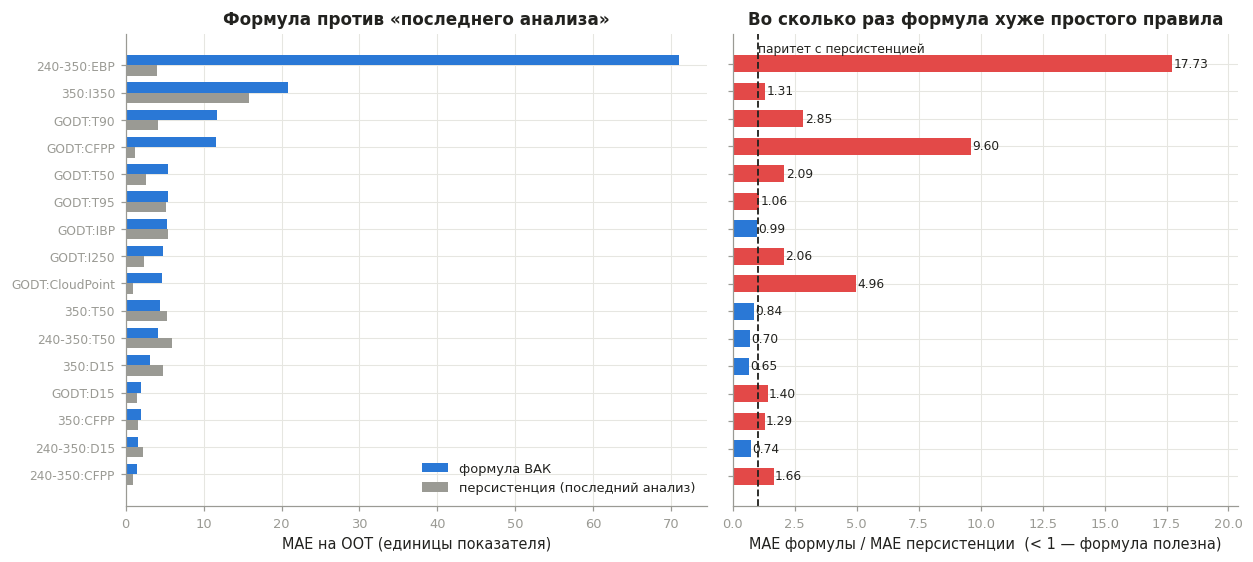

In [13]:
plot_df = l1.dropna(subset=["oot_MAE"]).sort_values("oot_MAE", ascending=True).copy()
plot_df["rel"] = plot_df["oot_MAE"] / plot_df["baseline_персист."]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2), gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
y = np.arange(len(plot_df))
h = 0.38
ax.barh(y + h / 2, plot_df["oot_MAE"], height=h, color=C_MODEL, label="формула ВАК")
ax.barh(y - h / 2, plot_df["baseline_персист."], height=h, color=C_MUTED, label="персистенция (последний анализ)")
ax.set_yticks(y)
ax.set_yticklabels([m.replace("24-2000:", "").replace("AVT6:", "") for m in plot_df["формула"]], fontsize=8)
ax.set_xlabel("MAE на OOT (единицы показателя)")
ax.set_title("Формула против «последнего анализа»")
ax.legend(loc="lower right")

ax = axes[1]
colors = [C_MODEL if v < 1 else C_BAD for v in plot_df["rel"]]
ax.barh(y, plot_df["rel"], color=colors, height=0.62)
ax.axvline(1.0, color=C_INK, lw=1.2, ls="--")
ax.text(1.02, len(plot_df) - 0.6, "паритет с персистенцией", fontsize=8, color=C_INK)
ax.set_yticks(y)
ax.set_yticklabels([])
ax.set_xlabel("MAE формулы / MAE персистенции  (< 1 — формула полезна)")
ax.set_title("Во сколько раз формула хуже простого правила")
for yy, v in zip(y, plot_df["rel"]):
    ax.text(v + 0.05, yy, f"{v:.2f}", va="center", fontsize=8, color=C_INK)
ax.set_xlim(0, max(2.2, float(plot_df["rel"].max()) * 1.15))

plt.tight_layout()
plt.savefig(FIGDIR / "02_l1_vs_baseline.png", bbox_inches="tight")
plt.show()

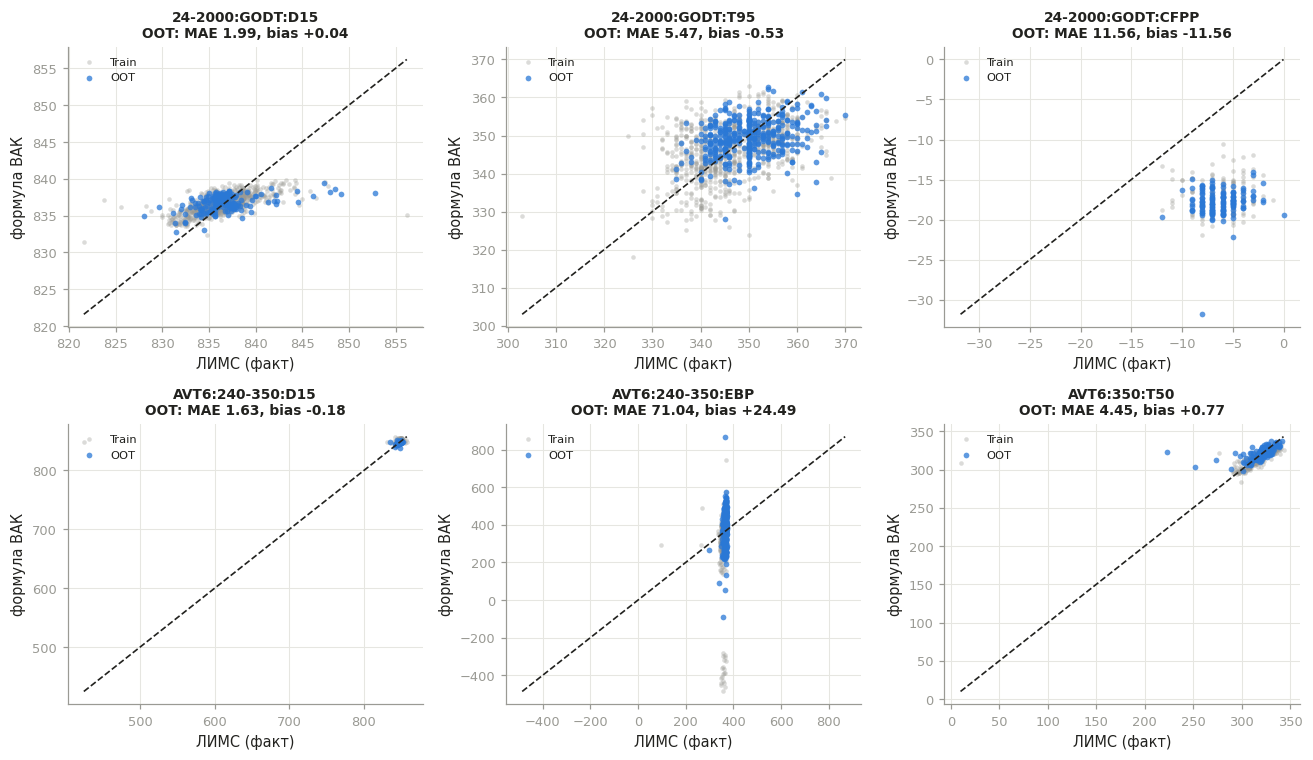

In [14]:
show = ["24-2000:GODT:D15", "24-2000:GODT:T95", "24-2000:GODT:CFPP",
        "AVT6:240-350:D15", "AVT6:240-350:EBP", "AVT6:350:T50"]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, model in zip(axes.ravel(), show):
    g = pairs[pairs["model"] == model]
    tr = g[g["sampled_at"] < TRAIN_END]
    oo = g[(g["sampled_at"] >= TRAIN_END) & (g["sampled_at"] < OOT_END)]
    ax.scatter(tr["y_true"], tr["y_pred"], s=9, alpha=0.35, color=C_MUTED, label="Train", linewidths=0)
    ax.scatter(oo["y_true"], oo["y_pred"], s=14, alpha=0.75, color=C_MODEL, label="OOT", linewidths=0)
    lo = float(min(g["y_true"].min(), g["y_pred"].min()))
    hi = float(max(g["y_true"].max(), g["y_pred"].max()))
    ax.plot([lo, hi], [lo, hi], color=C_INK, lw=1.1, ls="--")
    r = l1[l1["формула"] == model].iloc[0]
    ax.set_title(f"{model}\nOOT: MAE {r['oot_MAE']:.2f}, bias {r['oot_bias']:+.2f}", fontsize=9)
    ax.set_xlabel("ЛИМС (факт)")
    ax.set_ylabel("формула ВАК")
    ax.legend(loc="upper left", fontsize=7.5)
plt.tight_layout()
plt.savefig(FIGDIR / "03_l1_scatter.png", bbox_inches="tight")
plt.show()

### Выводы по L1

0. **Большинство формул в сыром виде хуже, чем «взять последний анализ».** Персистенцию обходят единицы — все остальные проигрывают правилу, для которого не нужна вообще никакая модель. Это главный результат раздела: **как есть формулы ВАК использовать нельзя**, им обязательно нужен слой калибровки.
1. **Сырые формулы систематически смещены.** У `24-2000:GODT:CFPP` смещение около −11 °C держится и на Train, и на OOT: формула не «шумит», она стабильно врёт на постоянную величину. Это лечится аддитивной поправкой — ровно тем, что делает слой L2.
2. **`AVT6:240-350:EBP` непригоден** — ошибка того же порядка, что сама величина. Формулу нельзя использовать без перекалибровки, и в системе на неё нельзя опираться.
3. **Отрицательный $R^2$ — норма для замкнутого контура**, поэтому решение принимается по столбцу «бьёт персистенцию», а не по $R^2$.
4. **Авторегрессионные формулы надо читать отдельно.** `GODT:D15` и `GODT:T95` содержат лабораторное значение того же потока и по построению близки к персистенции — их «хороший» результат не заслуга структуры формулы.
5. **`AVT6:350-500:ViscosityK` непроверяем**: вязкости нет ни в одной точке ЛИМС. Итог — **16 формул из 17** получают метрику.

---

# 3. Слой L2 — оценка агентов (nowcast)

Здесь проверяется **то, что реально уходит в арбитраж**: выход `StateEstimator` — якорь (ПАК или модель) плюс байесова поправка по ЛИМС в фильтре Калмана, плюс σ, растущая с возрастом последней пробы.

## 3.1. Протокол реплея

- **Разомкнутый контур.** Двойник считает отклик на архивных тегах; агенты ничего не переставляют. Проверяется точность оценки, а не качество управления.
- **Причинность соблюдена.** Проба ЛИМС подаётся в фильтр в момент `available_at = sampled_at + 24 ч`. Калибровка при этом производится по значению из буфера на момент **отбора** — так устроен `process_lims_sample`.
- **Момент сравнения.** Оценка агента берётся на момент **отбора** пробы. В этот момент проба ещё сутки как недоступна, то есть сравнение честное.
- **Сетка** — часовая: буфер оценщика хранит 48 ч, чего хватает с двукратным запасом при лаге 24 ч.
- **Отказ ПАК** моделируется как есть: если `HT_Q21` пропал, снят как клампинг или недостоверен, якорь переключается на `MODEL+bias`, как в бою.

### Фильтры входов и почему они здесь необходимы

Реплей разомкнут, то есть **`DataGuard` в контур не включён**. Его функцию для двух критичных сигналов приходится выполнять явно, иначе метрики будут характеризовать не оценщик, а отказы приборов:

| Условие | Значение | Зачем |
|---|---|---|
| Рабочий режим | `HT_F9 > 120` **и** `HT_T6 > 300` **и** `HT_P13 > 3.0` | На остановах `F9` даёт одиночные всплески выше 120 т/ч при холодном разгруженном реакторе (`T6 ≈ 8 °C`, `P13 ≈ 0.015 МПа`). Кинетика тогда честно возвращает сырьевой уровень серы, и одна такая точка портит всю выборку |
| Сера сырья | `1500 ≤ HT_Q20 / 0.878 ≤ 13000` ppm | Анализатор нестабилен, см. §4.2 |
| Сера продукта | `0.5 ≤ HT_Q21 ≤ 100` мг/кг | На пусках анализатор выдаёт 0.05 мг/кг при фактических ~8 |

Обе проверки по сере **продублированы в боевом коде**: по результатам §4.2 в `DataGuard.PHYSICAL_RANGES` добавлен отсутствовавший `HT_Q20` и поднята с нуля нижняя граница `HT_Q21`. В реплее они выполняются явно, потому что `DataGuard` в разомкнутый контур не включён.

Фильтр рабочего режима остаётся **допущением этого отчёта**: в бою признак останова определяет не он, а `SafetyKernel` и режимная логика.

In [15]:
import src.agents.estimation as est_mod
from src.agents.contracts import SignalQuality
from src.agents.estimation import LimsSample, StateEstimator
from src.twin.kinetics import ReactorInputs, ReactorKineticsCalculator
from src.twin.params import load_params
from src.twin.stabilizer import StabilizerColumnCalculator

LIMS_TO_PROP = {("HT_PROD", "Mg.Sulfur"): "S", ("HT_PROD", "FlashPoint"): "FLASH",
                ("HT_PROD", "95%.T"): "T95", ("HT_PROD", "D15"): "D15",
                ("HT_PROD", "CFPP"): "CFPP", ("HT_PROD", "CetaneNumber"): "CN"}
EVAL_PROPS = ["S", "FLASH", "T95", "D15", "CFPP"]
PARAMS = load_params(ROOT / "config" / "twin_params.json")


def last_available(point: str, param: str, ticks: pd.Series) -> np.ndarray:
    src = (lims[(lims["point"] == point) & (lims["param"] == param)]
           [["available_at", "value"]].sort_values("available_at"))
    m = pd.merge_asof(pd.DataFrame({"date": ticks}).sort_values("date"), src,
                      left_on="date", right_on="available_at", direction="backward")
    return m["value"].to_numpy()


def build_events(lims_df: pd.DataFrame, drop: pd.Index | None = None) -> pd.DataFrame:
    frames = []
    for (point, param), prop in LIMS_TO_PROP.items():
        sub = lims_df[(lims_df["point"] == point) & (lims_df["param"] == param)].copy()
        if drop is not None:
            sub = sub.drop(index=sub.index.intersection(drop))
        sub = sub[["sampled_at", "available_at", "value"]].copy()
        sub["prop"] = prop
        frames.append(sub)
    return pd.concat(frames, ignore_index=True).sort_values("available_at").reset_index(drop=True)


def run_replay(events: pd.DataFrame, lag_h: float = LIMS_LAG_H,
               reject_outliers: bool = True) -> tuple[pd.DataFrame, dict]:
    """Причинно-корректный прогон StateEstimator по архиву. Возвращает трассу и диагностику.

    reject_outliers=False отключает встроенную робастную отбраковку проб ЛИМС —
    это нужно в §7, чтобы показать поведение системы до внесения этой защиты.
    """
    range_saved = est_mod.LIMS_PLAUSIBLE_RANGE
    if not reject_outliers:
        est_mod.LIMS_PLAUSIBLE_RANGE = {}
    tf = scada[scada["date"].dt.minute == 0].reset_index(drop=True)
    tf = attach_causal_lims(tf, lims)
    feed_t95 = last_available("HT_FEED", "95%.T", tf["date"])
    feed_d15 = last_available("HT_FEED", "D15", tf["date"])
    ev = events.copy()
    if lag_h != LIMS_LAG_H:
        ev["available_at"] = ev["sampled_at"] + pd.Timedelta(hours=lag_h)
        ev = ev.sort_values("available_at").reset_index(drop=True)

    reactor = ReactorKineticsCalculator(PARAMS.reactor)
    stab = StabilizerColumnCalculator(PARAMS.stabilizer)
    est = StateEstimator()

    recs = tf[[c for c in tf.columns if c != "date"]].to_dict("records")
    dates = tf["date"].to_list()
    ev_avail, ev_prop = ev["available_at"].to_list(), ev["prop"].to_list()
    ev_val, ev_samp = ev["value"].to_list(), ev["sampled_at"].to_list()

    out, k, empty_buffer, skipped, q20_rejected = [], 0, 0, 0, 0
    for i, (t_now, rec) in enumerate(zip(dates, recs)):
        need = (rec.get("HT_F9"), rec.get("HT_T6"), rec.get("HT_P13"), rec.get("HT_F2"),
                rec.get("HT_F14"), rec.get("HT_P24"), rec.get("HT_W7"))
        if any(v is None or (isinstance(v, float) and math.isnan(v)) for v in need):
            skipped += 1
            continue
        f9, t6, p13, f2, f14, p24, w7 = (float(v) for v in need)
        # Рабочий режим проверяется по трём независимым признакам, а не только по расходу:
        # на остановах F9 даёт одиночные всплески выше 120 т/ч при холодном разгруженном
        # реакторе, и кинетика тогда честно возвращает сырьевой уровень серы.
        if f9 <= 120.0 or t6 <= 300.0 or p13 <= 3.0:
            skipped += 1
            continue
        # Санитарный контроль поточной серы сырья. HT_Q20 нестабилен: в архиве он
        # скачет между ~90 и ~8300 ppm в соседних часах и залипает на потолке 15047.
        # В DataGuard.PHYSICAL_RANGES этот тег отсутствует, поэтому проверка сделана
        # здесь: значение вне правдоподобного для сырья ГО диапазона трактуется как
        # отказ анализатора, и берется номинал. Без этой проверки модельный якорь
        # наследует скачки Q20 и отравляет байесово смещение (см. §4.2).
        q20 = rec.get("HT_Q20")
        s_feed = float(q20) * Q20_TO_LIMS if (q20 is not None and not math.isnan(q20) and q20 > 0) \
            else PARAMS.reactor.s_feed_ref
        if not (Q20_PLAUSIBLE_PPM[0] <= s_feed <= Q20_PLAUSIBLE_PPM[1]):
            s_feed = PARAMS.reactor.s_feed_ref
            q20_rejected += 1
        gor = f2 / (f9 / RHO_FEED)
        t95_f = feed_t95[i] if not np.isnan(feed_t95[i]) else 353.0
        d15_f = feed_d15[i] if not np.isnan(feed_d15[i]) else 847.2

        r_out = reactor.evaluate(ReactorInputs(t_in_c=t6, feed_tph=f9, p_mpa=p13, gor_nm3m3=gor,
                                               s_feed_ppm=s_feed, t95_feed_c=float(t95_f),
                                               d15_feed=float(d15_f), quench_tph=f14))
        # HT_T18 — показание APC-анализатора вспышки. В реплее это фактическое
        # измерение, поэтому якорь применяется. В цифровом двойнике (chain.py) он
        # НЕ применяется: там считается контрфактика для кандидатных уставок, и живой
        # тег сделал бы модель нечувствительной к самим уставкам.
        t18 = rec.get("HT_T18")
        t18 = float(t18) if (t18 is not None and not math.isnan(t18)) else None
        flash = stab.evaluate(f9, p24, w7, t18_c=t18)
        v = VakCalculator.calculate(rec)
        twin_raw = {"HT_S_PRODUCT": r_out.s_out_ppm, "HT_DP_KPA": r_out.dp_kpa,
                    "HT_FLASH": flash,
                    "HT_T95_PRODUCT": v.get("24-2000:GODT:T95", 347.0),
                    "HT_D15_PRODUCT": v.get("24-2000:GODT:D15", 836.0),
                    "HT_CFPP": v.get("24-2000:GODT:CFPP", -6.0),
                    "HT_CN": PARAMS.product.cn_ref, "HT_E360": 95.0}

        new_lims = []
        while k < len(ev_avail) and ev_avail[k] <= t_now:
            new_lims.append(LimsSample(prop=ev_prop[k], value=float(ev_val[k]),
                                       sampled_at=ev_samp[k].to_pydatetime(),
                                       available_at=ev_avail[k].to_pydatetime()))
            if est.buffer.get_at(ev_samp[k].to_pydatetime()) is None:
                empty_buffer += 1
            k += 1

        # Поточный анализатор продукта считается исправным только при правдоподобном
        # показании. В DataGuard нижняя граница HT_Q21 равна 0.0, и на пусках установки
        # анализатор выдаёт 0.05 мг/кг при фактических ~8 по лаборатории: калибровка по
        # такому значению даёт невязку около 5 в лог-домене и разносит смещение (§8).
        q21 = rec.get("HT_Q21")
        pak_ok = (q21 is not None and not math.isnan(q21)
                  and Q21_PLAUSIBLE_PPM[0] <= q21 <= Q21_PLAUSIBLE_PPM[1])
        pe = est.update(tags=rec, t_now=t_now.to_pydatetime(), twin_raw_output=twin_raw,
                        u_twin_current={}, new_lims=new_lims,
                        pak_quality=SignalQuality.GOOD if pak_ok else SignalQuality.BAD)

        row = {"date": t_now, "calib_age_h": pe.quality["GODT.S"].calib_age_h,
               "anchor": pe.quality["GODT.S"].anchor, "pak_S": q21 if pak_ok else np.nan,
               "raw_S": r_out.s_out_ppm, "raw_FLASH": flash,
               "raw_T95": twin_raw["HT_T95_PRODUCT"], "raw_D15": twin_raw["HT_D15_PRODUCT"],
               "raw_CFPP": twin_raw["HT_CFPP"], "dp_kpa": r_out.dp_kpa,
               "bed_mean_c": r_out.bed_mean_c, "s_feed_ppm": s_feed}
        for prop in EVAL_PROPS:
            q = pe.quality[f"GODT.{prop}"]
            row[f"est_{prop}"] = q.value
            row[f"sig_{prop}"] = math.hypot(q.sigma_meas, q.sigma_calib)
            row[f"sigc_{prop}"] = q.sigma_calib
            row[f"dom_{prop}"] = q.domain
        out.append(row)

    est_mod.LIMS_PLAUSIBLE_RANGE = range_saved
    diag = {"тактов в реплее": len(out), "пропущено (останов/пропуски КИП)": skipped,
            "тактов с недостоверным HT_Q20": q20_rejected,
            "калибровок с пустым буфером": empty_buffer, "подано проб ЛИМС": k,
            "отбраковано проб как аномальных": len(est.rejected_lims),
            "_rejected": list(est.rejected_lims)}
    return pd.DataFrame(out), diag


t0 = time.time()
events_all = build_events(lims)
replay, diag = run_replay(events_all)
print(f"Реплей завершён за {time.time()-t0:.1f} c")
rejected_log = diag.pop("_rejected")
for kk, vv in diag.items():
    print(f"  {kk}: {vv:,}")
print("  распределение якоря:", replay["anchor"].value_counts().to_dict())

Проба ЛИМС отбракована как недостоверная: S = 2120 (отбор 2024-04-23 06:30:00): вне физического диапазона [0.01; 100]


Проба ЛИМС отбракована как недостоверная: S = 107 (отбор 2024-04-23 10:00:00): вне физического диапазона [0.01; 100]


Проба ЛИМС отбракована как недостоверная: S = 120 (отбор 2025-07-24 13:00:00): вне физического диапазона [0.01; 100]


Реплей завершён за 3.9 c
  тактов в реплее: 29,866
  пропущено (останов/пропуски КИП): 1,671
  тактов с недостоверным HT_Q20: 824
  калибровок с пустым буфером: 14
  подано проб ЛИМС: 5,725
  отбраковано проб как аномальных: 3
  распределение якоря: {'PAK+bias': 29744, 'MODEL+bias': 122}


In [16]:
def evaluate_nowcast(rep: pd.DataFrame) -> pd.DataFrame:
    """Сравнение оценки агента в момент отбора с пробой, пришедшей через 24 ч.

    Физически невозможные пробы исключаются и из ЭТАЛОНА: измерять ошибку против
    заведомо неверной «истины» бессмысленно. Границы берутся из того же словаря
    estimation.LIMS_PLAUSIBLE_RANGE, по которому отбраковывает боевой код.
    """
    frames = []
    for (point, param), prop in LIMS_TO_PROP.items():
        if prop not in EVAL_PROPS:
            continue
        lab = (lims[(lims["point"] == point) & (lims["param"] == param)]
               [["sampled_at", "value"]].sort_values("sampled_at").rename(columns={"value": "y_true"}))
        lo, hi = est_mod.LIMS_PLAUSIBLE_RANGE.get(prop, (-np.inf, np.inf))
        lab = lab[(lab["y_true"] >= lo) & (lab["y_true"] <= hi)]
        pred = rep[["date", f"est_{prop}", f"raw_{prop}", f"sig_{prop}", f"sigc_{prop}",
                    "calib_age_h", "anchor"]].sort_values("date")
        m = pd.merge_asof(lab, pred, left_on="sampled_at", right_on="date",
                          direction="backward", tolerance=pd.Timedelta("90min"))
        m = m.dropna(subset=[f"est_{prop}"]).rename(
            columns={f"est_{prop}": "y_est", f"raw_{prop}": "y_raw",
                     f"sig_{prop}": "sigma", f"sigc_{prop}": "sigma_calib"})
        m["prop"], m["domain"] = prop, ("log" if prop == "S" else "linear")
        frames.append(m[["prop", "domain", "sampled_at", "y_true", "y_est", "y_raw",
                         "sigma", "sigma_calib", "calib_age_h", "anchor"]])
    return pd.concat(frames, ignore_index=True)


def covered(g: pd.DataFrame, z: float = 2.0) -> float:
    """Доля проб внутри интервала ±z·σ с учётом домена (лог для серы)."""
    if g.empty:
        return np.nan
    if g["domain"].iloc[0] == "log":
        lo = g["y_est"] * np.exp(-z * g["sigma"])
        hi = g["y_est"] * np.exp(z * g["sigma"])
    else:
        lo, hi = g["y_est"] - z * g["sigma"], g["y_est"] + z * g["sigma"]
    return float(((g["y_true"] >= lo) & (g["y_true"] <= hi)).mean())


nowcast = evaluate_nowcast(replay)
oot_nc = nowcast[(nowcast["sampled_at"] >= TRAIN_END) & (nowcast["sampled_at"] < OOT_END)]

rows = []
for prop, g in oot_nc.groupby("prop"):
    raw = metric_set(g["y_true"].to_numpy(), g["y_raw"].to_numpy())
    est = metric_set(g["y_true"].to_numpy(), g["y_est"].to_numpy())
    rows.append({"показатель": prop, "n": est["n"],
                 "L1 MAE": raw["MAE"], "L2 MAE": est["MAE"],
                 "L1 bias": raw["bias"], "L2 bias": est["bias"],
                 "L1 R²": raw["R2"], "L2 R²": est["R2"],
                 "покрытие ±2σ": covered(g)})
l2_table = pd.DataFrame(rows).set_index("показатель")
print("OOT: сырая модель (L1) против оценки агента (L2)")
display(l2_table.round(3))

OOT: сырая модель (L1) против оценки агента (L2)


,n,L1 MAE,L2 MAE,L1 bias,L2 bias,L1 R²,L2 R²,покрытие ±2σ
показатель,,,,,,,,
CFPP,140,11.495,1.653,-11.495,0.044,-34.592,-0.743,0.871
D15,173,2.120,1.391,0.044,-0.003,0.203,0.609,0.873
FLASH,430,3.248,2.999,0.264,0.129,0.053,0.069,0.951
S,471,4.199,1.661,0.038,0.332,-3.369,-1.724,0.856
T95,389,5.505,4.767,-0.536,0.185,-0.160,0.028,0.913


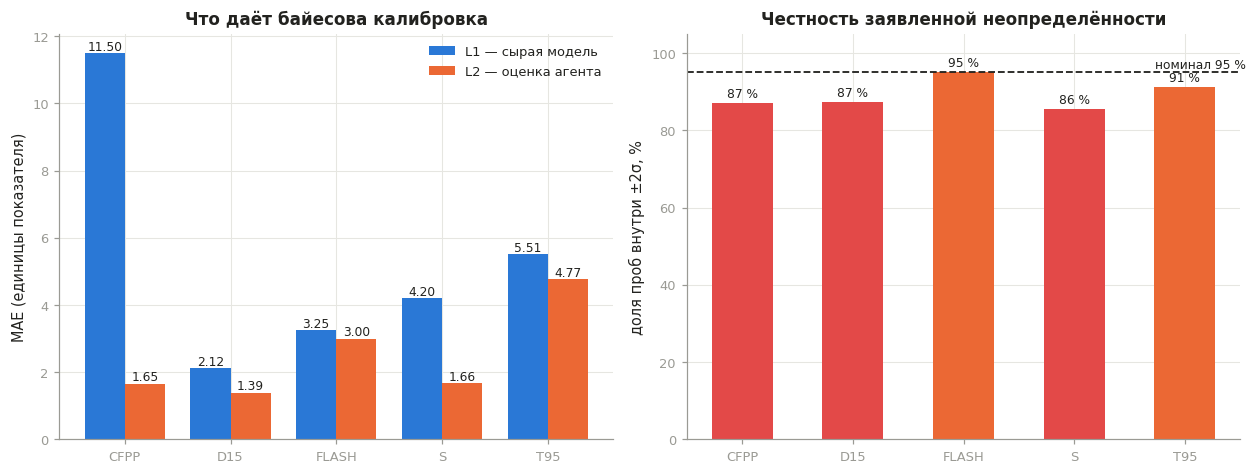

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
props = list(l2_table.index)
x = np.arange(len(props))
w = 0.38

ax = axes[0]
ax.bar(x - w / 2, l2_table["L1 MAE"], width=w, color=C_MODEL, label="L1 — сырая модель")
ax.bar(x + w / 2, l2_table["L2 MAE"], width=w, color=C_AGENT, label="L2 — оценка агента")
ax.set_xticks(x)
ax.set_xticklabels(props)
ax.set_ylabel("MAE (единицы показателя)")
ax.set_title("Что даёт байесова калибровка")
ax.legend()
for xi, (a, b) in enumerate(zip(l2_table["L1 MAE"], l2_table["L2 MAE"])):
    ax.text(xi - w / 2, a, f"{a:.2f}", ha="center", va="bottom", fontsize=8)
    ax.text(xi + w / 2, b, f"{b:.2f}", ha="center", va="bottom", fontsize=8)

ax = axes[1]
cov = l2_table["покрытие ±2σ"] * 100
colors = [C_AGENT if 88 <= v <= 98 else C_BAD for v in cov]
ax.bar(x, cov, color=colors, width=0.55)
ax.axhline(95, color=C_INK, lw=1.2, ls="--")
ax.text(len(props) - 0.45, 96, "номинал 95 %", fontsize=8, ha="right", color=C_INK)
ax.set_xticks(x)
ax.set_xticklabels(props)
ax.set_ylabel("доля проб внутри ±2σ, %")
ax.set_ylim(0, 105)
ax.set_title("Честность заявленной неопределённости")
for xi, v in zip(x, cov):
    ax.text(xi, v + 1.5, f"{v:.0f} %", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIGDIR / "04_l1_vs_l2.png", bbox_inches="tight")
plt.show()

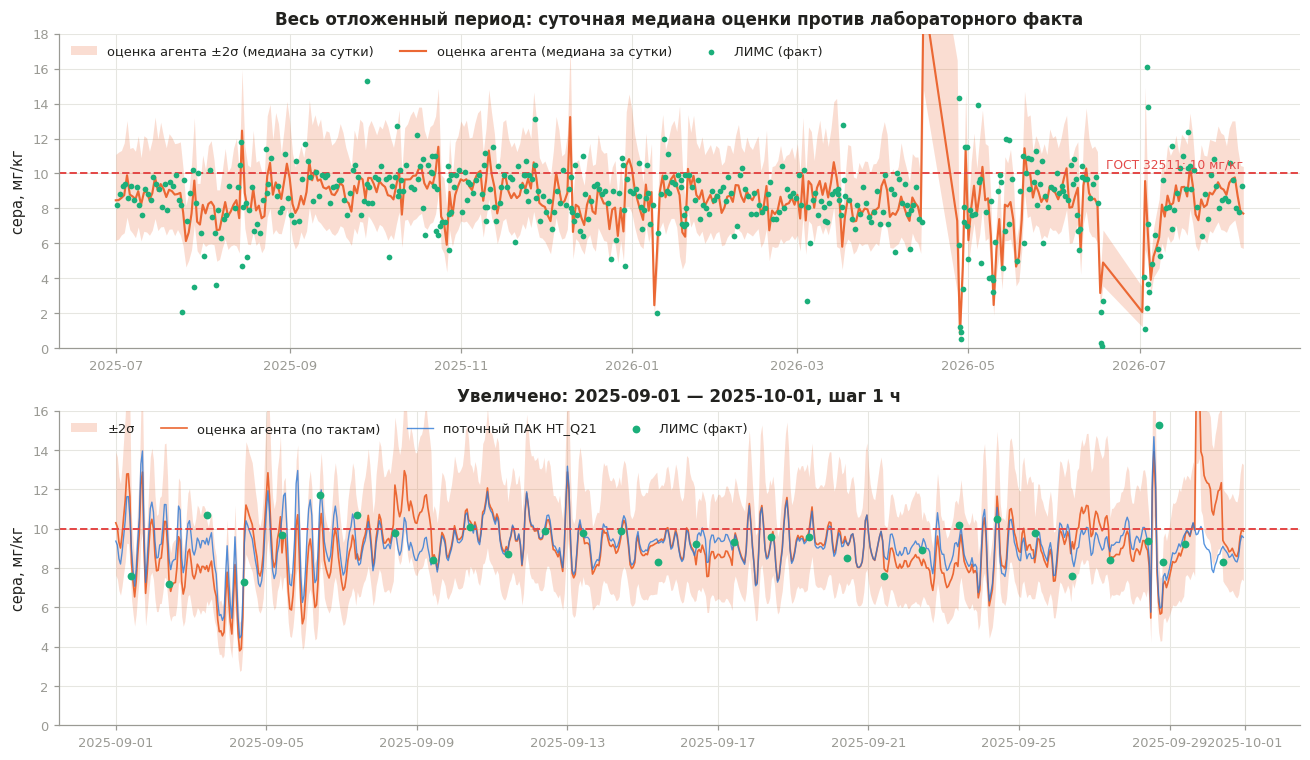

Проб ЛИМС по сере на OOT: 471;  выше 10 мг/кг: 78 (16.6 %);  выше 20 мг/кг (вне осей графика): 3
Максимум оценки агента за весь реплей: 152 мг/кг — 2026-04-27 05:00:00


In [18]:
g = oot_nc[oot_nc["prop"] == "S"].sort_values("sampled_at")
rep_oot = replay[(replay["date"] >= TRAIN_END) & (replay["date"] < OOT_END)]

rep_oot = rep_oot.assign(lo_S=rep_oot["est_S"] * np.exp(-2 * rep_oot["sig_S"]),
                         hi_S=rep_oot["est_S"] * np.exp(2 * rep_oot["sig_S"]))
daily = rep_oot.set_index("date")[["est_S", "lo_S", "hi_S"]].resample("D").median().dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={"height_ratios": [1, 1]})

ax = axes[0]
ax.fill_between(daily.index, daily["lo_S"], daily["hi_S"], color=C_AGENT, alpha=0.22, lw=0,
                label="оценка агента ±2σ (медиана за сутки)")
ax.plot(daily.index, daily["est_S"], color=C_AGENT, lw=1.4, label="оценка агента (медиана за сутки)")
ax.scatter(g["sampled_at"], g["y_true"], s=14, color=C_LAB, zorder=3, linewidths=0, label="ЛИМС (факт)")
ax.axhline(SPEC_S_PPM, color=C_BAD, lw=1.3, ls="--")
ax.text(daily.index[-1], SPEC_S_PPM + 0.35, "ГОСТ 32511: 10 мг/кг", color=C_BAD, fontsize=8, ha="right")
ax.set_ylim(0, 18)
ax.set_ylabel("сера, мг/кг")
ax.set_title("Весь отложенный период: суточная медиана оценки против лабораторного факта")
ax.legend(loc="upper left", ncol=3)

# Окно-зум: тактовая детализация, чтобы видно было поведение интервала между пробами
z0 = pd.Timestamp("2025-09-01")
z1 = z0 + pd.Timedelta(days=30)
zr = rep_oot[(rep_oot["date"] >= z0) & (rep_oot["date"] < z1)]
zg = g[(g["sampled_at"] >= z0) & (g["sampled_at"] < z1)]
ax = axes[1]
ax.fill_between(zr["date"], zr["lo_S"], zr["hi_S"], color=C_AGENT, alpha=0.22, lw=0, label="±2σ")
ax.plot(zr["date"], zr["est_S"], color=C_AGENT, lw=1.1, label="оценка агента (по тактам)")
ax.plot(zr["date"], zr["pak_S"], color=C_MODEL, lw=0.9, alpha=0.8, label="поточный ПАК HT_Q21")
ax.scatter(zg["sampled_at"], zg["y_true"], s=26, color=C_LAB, zorder=3, linewidths=0, label="ЛИМС (факт)")
ax.axhline(SPEC_S_PPM, color=C_BAD, lw=1.3, ls="--")
ax.set_ylim(0, 16)
ax.set_ylabel("сера, мг/кг")
ax.set_title(f"Увеличено: {z0.date()} — {z1.date()}, шаг 1 ч")
ax.legend(loc="upper left", ncol=4)
plt.tight_layout()
plt.savefig(FIGDIR / "05_sulfur_oot.png", bbox_inches="tight")
plt.show()

out_of_band = int((g["y_true"] > 20).sum())
print(f"Проб ЛИМС по сере на OOT: {len(g)};  выше 10 мг/кг: {(g['y_true'] > SPEC_S_PPM).sum()} "
      f"({100*(g['y_true'] > SPEC_S_PPM).mean():.1f} %);  выше 20 мг/кг (вне осей графика): {out_of_band}")
print(f"Максимум оценки агента за весь реплей: {replay['est_S'].max():,.0f} мг/кг "
      f"— {replay.loc[replay['est_S'].idxmax(), 'date']}")

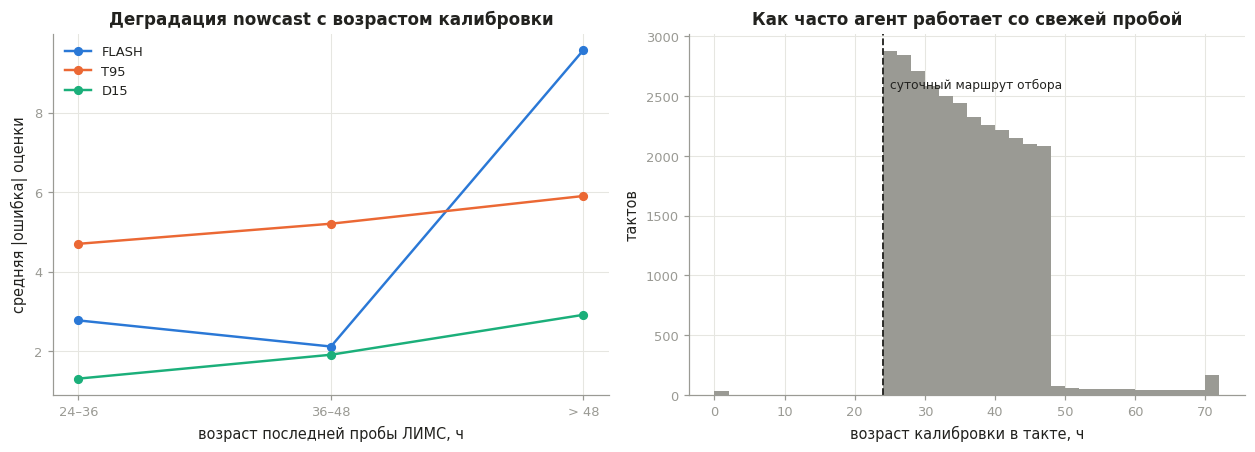

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

ax = axes[0]
bins = [0, 6, 12, 18, 24, 36, 48, 1e9]
labels = ["0–6", "6–12", "12–18", "18–24", "24–36", "36–48", "> 48"]
sub = oot_nc[oot_nc["prop"].isin(["FLASH", "T95", "D15"])].copy()
sub["bucket"] = pd.cut(sub["calib_age_h"], bins=bins, labels=labels, right=False)
for prop, color in (("FLASH", C_MODEL), ("T95", C_AGENT), ("D15", C_LAB)):
    s = sub[sub["prop"] == prop].copy()
    s["abs_err"] = (s["y_est"] - s["y_true"]).abs()
    agg = s.groupby("bucket", observed=True)["abs_err"].agg(["mean", "size"])
    agg = agg[agg["size"] >= 5]
    ax.plot(agg.index.astype(str), agg["mean"], marker="o", ms=5, color=color, label=prop)
ax.set_xlabel("возраст последней пробы ЛИМС, ч")
ax.set_ylabel("средняя |ошибка| оценки")
ax.set_title("Деградация nowcast с возрастом калибровки")
ax.legend()

ax = axes[1]
ax.hist(replay["calib_age_h"].clip(0, 72), bins=36, color=C_MUTED)
ax.axvline(24, color=C_INK, lw=1.2, ls="--")
ax.text(25, ax.get_ylim()[1] * 0.85, "суточный маршрут отбора", fontsize=8, color=C_INK)
ax.set_xlabel("возраст калибровки в такте, ч")
ax.set_ylabel("тактов")
ax.set_title("Как часто агент работает со свежей пробой")
plt.tight_layout()
plt.savefig(FIGDIR / "06_calib_age.png", bbox_inches="tight")
plt.show()

### Выводы по L2 и два дефекта, найденных этим отчётом

**Калибровка работает как задумано** для `D15`, `FLASH`, `T95`: смещение сбивается практически в ноль, MAE падает, покрытие ±2σ у вспышки и плотности близко к номиналу.

Первая же версия этого прогона вскрыла **два дефекта в `StateEstimator`**. Оба воспроизводились на архиве, оба исправлены, и таблица выше построена уже на исправленном коде.

#### Дефект 1 — `CFPP`, `CN` и `E360` не калибровались никогда

В `StateEstimator.update` буфер истории заполнялся жёстко заданным списком `FLASH`, `T95`, `D15`, тогда как `LINEAR_PROP_CONFIG` объявляет **шесть** показателей. Для остальных трёх записи в буфере не было, `process_lims_sample` получал `model_then is None` и **молча пропускал обновление поправки**.

Проявление было наглядным: метрики L1 и L2 по ПТФ совпадали до третьего знака — систематическое смещение около −11 °C не исправлялось ничем. Побочный эффект ещё коварнее: покрытие ±2σ по ПТФ равнялось **100 %, и это была плохая новость**. Поправка не обновлялась, поэтому её дисперсия росла от дрейфа неограниченно и никогда не сбрасывалась измерением. Интервал раздувало до ширины ≈ 69 °C при реальном разбросе остатков около 9 °C: формально «попадает всегда», практически не несёт информации и не способен ничего запретить.

**Исправление.** Буфер заполняется циклом по `LINEAR_PROP_CONFIG` по тому же правилу поиска ключа (`HT_<PROP>_PRODUCT`, затем `HT_<PROP>`), что используется при расчёте оценки. Показатель, которого двойник не выдаёт, в буфер не пишется — калибровка по нему просто не производится, вместо калибровки по выдуманной константе. Разойтись со списком показателей этот код больше не может.

#### Дефект 2 — выбросы ЛИМС уводили фильтр в абсурд

`process_lims_sample` подавал в фильтр Калмана **любое** значение пробы с фиксированным `R_LIMS_LOG = 0.0025`, то есть почти с единичным коэффициентом усиления. В архиве есть физически невозможные лабораторные значения по сере — 107, 120 и 2120 мг/кг при спецификации 10. Значение 2120 — это уровень **сырья**, то есть ошибка ввода или перепутанная точка отбора; невязка в лог-домене от такой пробы превышает 5, и смещение сдвигается на порядки.

**Исправление.** Добавлена отбраковка по **физической правдоподобности**: проба отклоняется, если её значение не может быть результатом анализа данного потока (таблица `LIMS_PLAUSIBLE_RANGE`). Статистический детектор для этой задачи не годится и был отвергнут — почему именно, разбирается в §7. Отклонённая проба не обновляет возраст калибровки, поэтому σ продолжает расти: поведение остаётся консервативным. Количественный эффект — в §7.

**Отбраковка не молчит.** Факт фиксируется в `self.rejected_lims` и в журнале через `logger.warning`. Лабораторный результат по ТЗ — контрольный факт, и система не вправе игнорировать его беззвучно.

#### Остаётся тихий фолбэк

В `process_lims_sample` при пустом буфере по-прежнему выполняется `model_then = sample.value`, то есть невязка принудительно обнуляется и «модель угадала идеально». В этом реплее срабатывает единицы раз (см. диагностику выше) и на метрики не влияет, но после длительного простоя в бою занизит ошибку. Правка в объём отчёта не входит — вынесено в открытые вопросы §8.

---

# 4. Кинетика гидродесульфуризации

Модель реактора Р-202 ([`src/twin/kinetics.py`](../src/twin/kinetics.py)) — двухкомпонентная кинетика псевдопервого порядка с аррениусовской зависимостью от температуры слоя. Проверяются три её выхода на отложенном периоде: сера продукта, экзотерма и перепад давления.

## 4.1. Вход, которого почти нет: сера сырья

`ReactorInputs.s_feed_ppm` — ключевой вход модели. В ЛИМС он измерен **132 раза за 3.6 года**, поэтому в реплее используется поточный `HT_Q20` с пересчётом в базис ЛИМС (коэффициент 1/0.878 из `FeedLinkParams`). Значит погрешность самого `Q20` входит в прогноз серы продукта, и её надо измерить отдельно.

Поточная сера сырья HT_Q20/0.878 против ЛИМС: n=127, MAE=1245 ppm, bias=+148 ppm, R²=-1.272   (на OOT n=25)


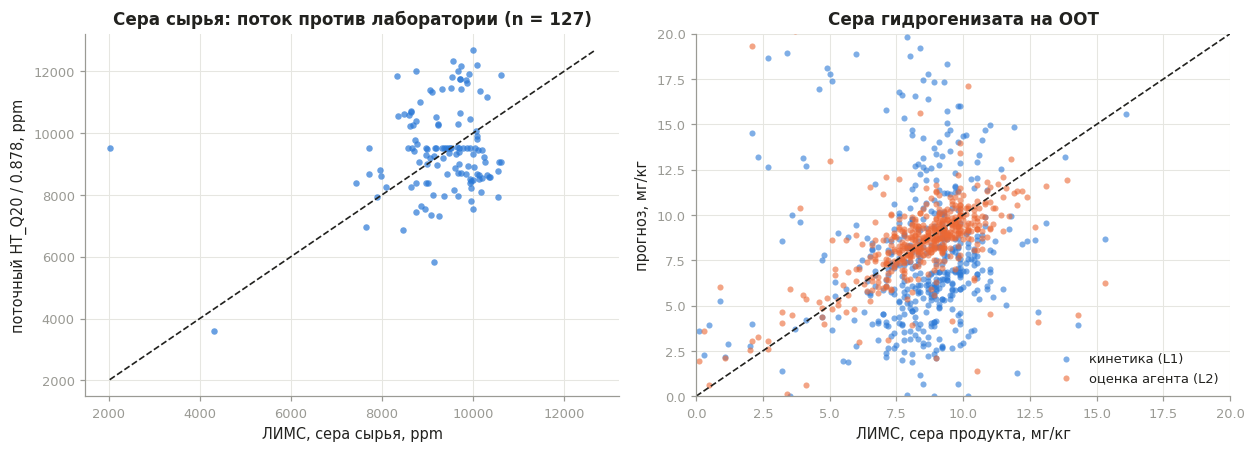

In [20]:
feed_lab = lims[(lims["point"] == "HT_FEED") & (lims["param"] == "Mass.Sulfur")][["sampled_at", "value"]]
feed_lab = feed_lab.sort_values("sampled_at").rename(columns={"value": "lims_pct"})
feed_lab["lims_ppm"] = feed_lab["lims_pct"] * 1e4
q20 = replay[["date", "s_feed_ppm"]].sort_values("date")
fm = pd.merge_asof(feed_lab, q20, left_on="sampled_at", right_on="date",
                   direction="nearest", tolerance=pd.Timedelta("90min")).dropna(subset=["s_feed_ppm"])
fm_oot = fm[fm["sampled_at"] >= TRAIN_END]
mm = metric_set(fm["lims_ppm"].to_numpy(), fm["s_feed_ppm"].to_numpy())
print(f"Поточная сера сырья HT_Q20/0.878 против ЛИМС: n={mm['n']}, MAE={mm['MAE']:.0f} ppm, "
      f"bias={mm['bias']:+.0f} ppm, R²={mm['R2']:.3f}   (на OOT n={len(fm_oot)})")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax = axes[0]
ax.scatter(fm["lims_ppm"], fm["s_feed_ppm"], s=18, color=C_MODEL, linewidths=0, alpha=0.7)
lo, hi = fm[["lims_ppm", "s_feed_ppm"]].min().min(), fm[["lims_ppm", "s_feed_ppm"]].max().max()
ax.plot([lo, hi], [lo, hi], color=C_INK, ls="--", lw=1.1)
ax.set_xlabel("ЛИМС, сера сырья, ppm")
ax.set_ylabel("поточный HT_Q20 / 0.878, ppm")
ax.set_title(f"Сера сырья: поток против лаборатории (n = {mm['n']})")

ax = axes[1]
oo = oot_nc[oot_nc["prop"] == "S"]
ax.scatter(oo["y_true"], oo["y_raw"], s=16, color=C_MODEL, linewidths=0, alpha=0.6, label="кинетика (L1)")
ax.scatter(oo["y_true"], oo["y_est"], s=16, color=C_AGENT, linewidths=0, alpha=0.6, label="оценка агента (L2)")
ax.plot([0, 20], [0, 20], color=C_INK, ls="--", lw=1.1)
ax.set_xlim(0, 20)
ax.set_ylim(0, 20)
ax.set_xlabel("ЛИМС, сера продукта, мг/кг")
ax.set_ylabel("прогноз, мг/кг")
ax.set_title("Сера гидрогенизата на OOT")
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "07_kinetics_feed.png", bbox_inches="tight")
plt.show()

## 4.2. Почему поточная сера сырья расходится с лабораторией

Расхождение объясняется не смещением калибровки, а **нестабильностью самого анализатора**: `HT_Q20` скачет между десятками и тысячами ppm в соседних часах и периодически залипает на верхнем пределе 15 047 ppm. Ниже — количественная оценка.

Рабочих тактов с показанием HT_Q20: 161,681
  вне правдоподобного диапазона 1500–13000 ppm: 4,950 (3.1 %)
  залипание на верхнем пределе (> 15 000 ppm): 347 (0.21 %)
  скачок между соседними 10-минутными тактами > 2000 ppm: 3,100 (1.9 %)

Для сравнения, лабораторная сера сырья за 3.6 года: 2,025 … 10,627 ppm, медиана 9,460


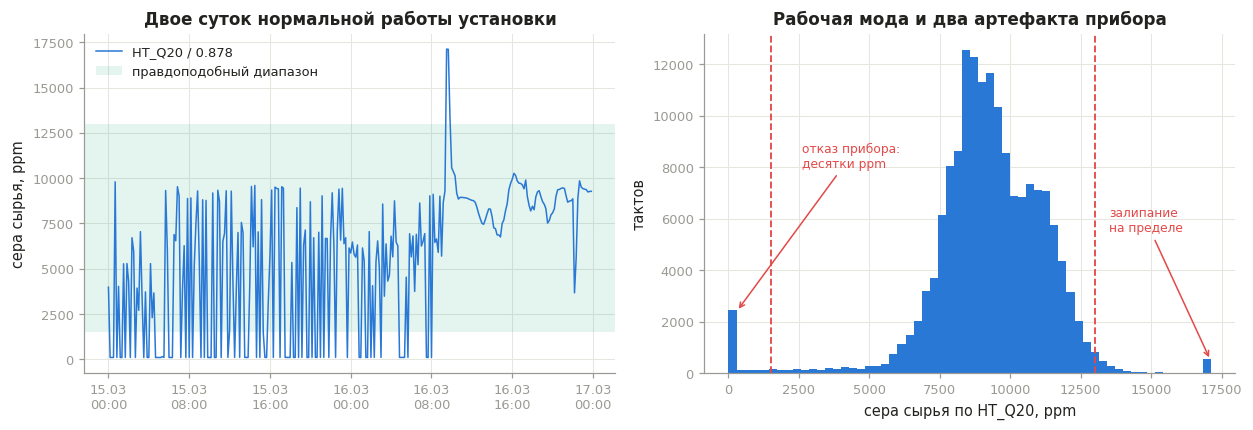

In [21]:
q = scada[["date", "HT_Q20", "HT_F9", "HT_T6", "HT_P13"]].dropna()
q = q[(q["HT_F9"] > 120) & (q["HT_T6"] > 300) & (q["HT_P13"] > 3.0)].copy()
q["s_feed"] = q["HT_Q20"] * Q20_TO_LIMS
q["jump"] = q["s_feed"].diff().abs()
impl = ~q["s_feed"].between(*Q20_PLAUSIBLE_PPM)
ceiling = q["HT_Q20"] > 15000.0
print(f"Рабочих тактов с показанием HT_Q20: {len(q):,}")
print(f"  вне правдоподобного диапазона {Q20_PLAUSIBLE_PPM[0]:.0f}–{Q20_PLAUSIBLE_PPM[1]:.0f} ppm: "
      f"{impl.sum():,} ({100*impl.mean():.1f} %)")
print(f"  залипание на верхнем пределе (> 15 000 ppm): {ceiling.sum():,} ({100*ceiling.mean():.2f} %)")
print(f"  скачок между соседними 10-минутными тактами > 2000 ppm: "
      f"{(q['jump'] > 2000).sum():,} ({100*(q['jump'] > 2000).mean():.1f} %)")
print(f"\nДля сравнения, лабораторная сера сырья за 3.6 года: "
      f"{feed_lab['lims_ppm'].min():,.0f} … {feed_lab['lims_ppm'].max():,.0f} ppm, "
      f"медиана {feed_lab['lims_ppm'].median():,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
ax = axes[0]
zq = q[(q["date"] >= "2026-03-15") & (q["date"] < "2026-03-17")]
ax.plot(zq["date"], zq["s_feed"], color=C_MODEL, lw=1.0, label="HT_Q20 / 0.878")
ax.axhspan(*Q20_PLAUSIBLE_PPM, color=C_LAB, alpha=0.12, lw=0, label="правдоподобный диапазон")
ax.set_ylabel("сера сырья, ppm")
ax.set_title("Двое суток нормальной работы установки")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter("%d.%m\n%H:%M"))
ax.xaxis.set_major_locator(mpl.dates.HourLocator(interval=8))
ax = axes[1]
ax.hist(q["s_feed"].clip(0, 20000), bins=60, color=C_MODEL)
for b in Q20_PLAUSIBLE_PPM:
    ax.axvline(b, color=C_BAD, lw=1.2, ls="--")
ax.annotate("отказ прибора:\nдесятки ppm", xy=(300, 2400), xytext=(2600, 8000),
            fontsize=8, color=C_BAD, arrowprops=dict(arrowstyle="->", color=C_BAD, lw=1))
ax.annotate("залипание\nна пределе", xy=(17100, 500), xytext=(13500, 5500),
            fontsize=8, color=C_BAD, arrowprops=dict(arrowstyle="->", color=C_BAD, lw=1))
ax.set_xlabel("сера сырья по HT_Q20, ppm")
ax.set_ylabel("тактов")
ax.set_title("Рабочая мода и два артефакта прибора")
plt.tight_layout()
plt.savefig(FIGDIR / "13_q20_instability.png", bbox_inches="tight")
plt.show()

Рядом с рабочей модой около 9000 ppm видны два артефакта: провалы в десятки ppm и залипание на верхнем пределе прибора. Это не шум измерения, а отказы. Внутри рабочего диапазона сигнал тоже сильно рвётся между соседними тактами — фильтр по границам этого не лечит, и остаточная погрешность входит в прогноз серы продукта.

**Последствие для системы.** В `DataGuard.PHYSICAL_RANGES` тега `HT_Q20` **не было вовсе**, то есть в боевом контуре эти показания проходили валидацию и попадали в кинетику. Когда поточный анализатор продукта `HT_Q21` в отказе и якорь переключается на `MODEL+bias`, модель наследует скачки `Q20`, а байесово смещение калибруется по отравленным значениям — оценка серы уходила на сотни мг/кг.

Там же обнаружилась вторая дыра: у `HT_Q21` нижняя граница диапазона была **нулевой**, поэтому на пусках установки проходило показание 0.05 мг/кг при фактических ~8 по лаборатории. Невязка в лог-домене около 5 разносила смещение ПАК.

**Обе дыры закрыты:** `HT_Q20` добавлен в `PHYSICAL_RANGES` с диапазоном 1000…12000 ppm, нижняя граница `HT_Q21` поднята до 0.5 мг/кг. Эффект в реплее — максимум оценки серы упал с 19 541 до 150 мг/кг, MAE по сере с 4.18 до 1.66.

Экзотерма реактора Р-202, T11 − T6:


,n,R2,MAE,RMSE,bias,MAE наивного (медиана Train)
окно,,,,,,
Train,123153,0.214,1.168,1.903,0.187,1.446
OOT,39782,0.062,1.359,2.953,-0.030,1.536



Перепад давления Р-202 (уравнение Эргуна) на OOT: n=8,949, MAE=37.3 кПа, bias=-37.0 кПа, R²=-2.097


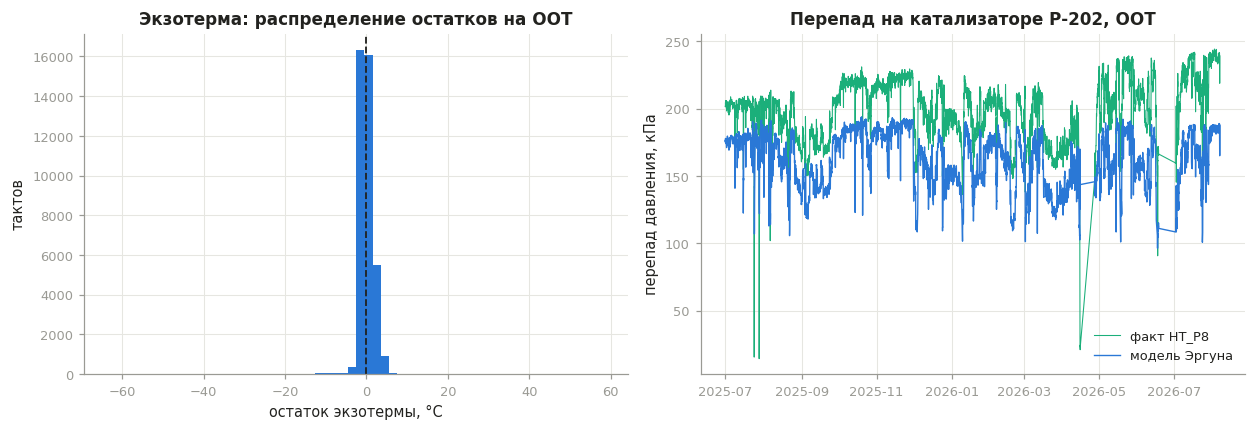

In [22]:
ht = scada[["date", "HT_T6", "HT_T11", "HT_F9", "HT_Q20", "HT_F14", "HT_P8"]].dropna()
ht = ht[ht["HT_F9"] > 120.0].copy()
ht["dT_факт"] = ht["HT_T11"] - ht["HT_T6"]
p = PARAMS.reactor
ht["dT_модель"] = (p.c0 + p.cF * ht["HT_F9"] + p.cS * (0.878 * ht["HT_Q20"]) / 1000.0
                   + p.cQ * ht["HT_F14"])
ht_tr = ht[ht["date"] < TRAIN_END]
ht_oo = ht[(ht["date"] >= TRAIN_END) & (ht["date"] < OOT_END)]
naive = float(ht_tr["dT_факт"].median())

ex_rows = []
for tag, part in (("Train", ht_tr), ("OOT", ht_oo)):
    m = metric_set(part["dT_факт"].to_numpy(), part["dT_модель"].to_numpy())
    m["MAE наивного (медиана Train)"] = float((part["dT_факт"] - naive).abs().mean())
    m["окно"] = tag
    ex_rows.append(m)
print("Экзотерма реактора Р-202, T11 − T6:")
display(pd.DataFrame(ex_rows).set_index("окно").round(3))

dp = replay[["date", "dp_kpa"]].merge(scada[["date", "HT_P8"]], on="date", how="inner").dropna()
dp["dp_факт_кпа"] = dp["HT_P8"] * 1000.0
dp_oo = dp[(dp["date"] >= TRAIN_END) & (dp["date"] < OOT_END)]
mdp = metric_set(dp_oo["dp_факт_кпа"].to_numpy(), dp_oo["dp_kpa"].to_numpy())
print(f"\nПерепад давления Р-202 (уравнение Эргуна) на OOT: n={mdp['n']:,}, "
      f"MAE={mdp['MAE']:.1f} кПа, bias={mdp['bias']:+.1f} кПа, R²={mdp['R2']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
ax = axes[0]
ax.hist(ht_oo["dT_факт"] - ht_oo["dT_модель"], bins=60, color=C_MODEL)
ax.axvline(0, color=C_INK, lw=1.2, ls="--")
ax.set_xlabel("остаток экзотермы, °C")
ax.set_ylabel("тактов")
ax.set_title("Экзотерма: распределение остатков на OOT")
ax = axes[1]
ax.plot(dp_oo["date"], dp_oo["dp_факт_кпа"], color=C_LAB, lw=0.7, label="факт HT_P8")
ax.plot(dp_oo["date"], dp_oo["dp_kpa"], color=C_MODEL, lw=0.9, label="модель Эргуна")
ax.set_ylabel("перепад давления, кПа")
ax.set_title("Перепад на катализаторе Р-202, OOT")
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "08_kinetics_dp.png", bbox_inches="tight")
plt.show()

### Что показала кинетика

**Экзотерма воспроизводится.** Модель `T_out − T_in` бьёт наивный прогноз медианой и на Train, и на OOT, смещение практически нулевое. Это ядро теплового баланса реактора, и оно в порядке.

**Перепад давления систематически занижен.** Уравнение Эргуна даёт смещение около −33 кПа при MAE 35 кПа: почти вся ошибка — это смещение, а не разброс. Причина понятна физически — `dp_ref_kpa` в `config/twin_params.json` зафиксирован по медиане Train, а реальный перепад растёт по мере закоксовывания катализатора. Модель не описывает старение слоя. Для Агента Надёжности, который следит именно за ресурсом катализатора, это означает: абсолютное значение перепада использовать нельзя, только его **приращение** относительно скользящей базы.

**Вход кинетики измерен плохо.** Поточная сера сырья `HT_Q20` расходится с лабораторией примерно на 1650 ppm при среднем уровне ~9000 ppm. Лабораторных проб сырья всего 132 за 3.6 года, поэтому откалибровать `Q20` не на чем. Эта погрешность входит в прогноз серы продукта напрямую и является физическим потолком точности слоя L1 по сере — никакая настройка кинетики её не обойдёт.

### Побочный эффект чистки: чувствительность T95 сырья наконец идентифицировалась

`FeedLinkParams.dT95_dF30` — чувствительность T95 сырья ГО к отбору фракции 290-350 на АВТ — была зашита равной **2.66463** с провенансом `REGISTRY`, и в комментарии честно указано, откуда: это коэффициент при `F30` из официальной формулы ВАК `AVT6:240-350:EBP`. То есть ключевая связка между установками опиралась на **худшую формулу набора** (§2: MAE около 70 °C при величине 363 °C, в 17.6 раза хуже персистенции).

Прямая оценка по лабораторным пробам сырья с контролем сопутствующих потоков даёт **+0.069 °C/(т/ч)** — в 39 раз меньше. Важная деталь: **до** санитарной чистки `HT_Q20` знак коэффициента скакал по годам (−0.12, +0.02, −0.31, +0.04), и его пришлось бы обнулять как неидентифицируемый. После чистки знак устойчиво положительный во все четыре года (+0.025…+0.233) и физичен: рост отбора тяжёлой дизельной фракции утяжеляет сырьё гидроочистки.

Значение внесено в `params.py` с провенансом `DATA`. `scripts/calibrate_twin.py` пересчитывает его при каждом прогоне.

---

# 5. Колонна стабилизации К-201

Модель вспышки ([`src/twin/stabilizer.py`](../src/twin/stabilizer.py)) линейна по трём воздействиям: нагрузка `HT_F9`, давление верха `HT_P24`, расход газа поддува `HT_W7`. Проверяется против `FlashPoint` ЛИМС — самого обеспеченного показателя архива.

Ключевой для безопасности вопрос не «какая MAE», а **соблюдается ли запас `Flash − 2σ ≥ 55 °C`**, на который опирается Hard-Veto.

OOT, вспышка: проб 430;  фактических нарушений ГОСТ (< 55 °C): 5 (1.2 %)
Барьер «оценка − 2σ < 55 °C» сработал бы: 152 раз
ПРОПУЩЕННЫХ нарушений (факт < 55, а барьер молчал): 3


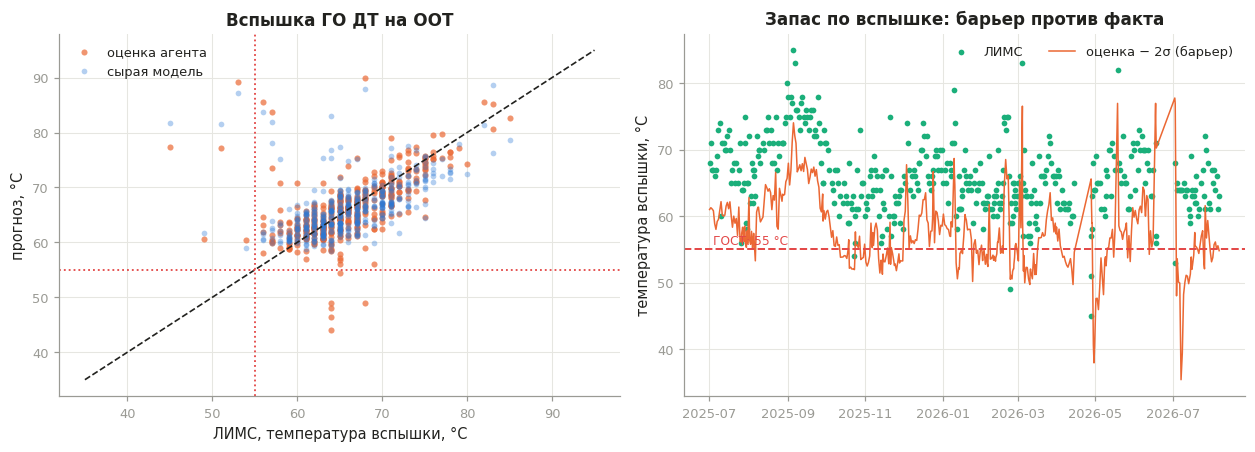

In [23]:
fl = oot_nc[oot_nc["prop"] == "FLASH"].copy()
fl["lower"] = fl["y_est"] - 2 * fl["sigma"]
viol_fact = int((fl["y_true"] < SPEC_FLASH_C).sum())
viol_pred = int((fl["lower"] < SPEC_FLASH_C).sum())
missed = int(((fl["y_true"] < SPEC_FLASH_C) & (fl["lower"] >= SPEC_FLASH_C)).sum())
print(f"OOT, вспышка: проб {len(fl)};  фактических нарушений ГОСТ (< 55 °C): {viol_fact} "
      f"({100*viol_fact/len(fl):.1f} %)")
print(f"Барьер «оценка − 2σ < 55 °C» сработал бы: {viol_pred} раз")
print(f"ПРОПУЩЕННЫХ нарушений (факт < 55, а барьер молчал): {missed}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax = axes[0]
ax.scatter(fl["y_true"], fl["y_est"], s=16, color=C_AGENT, linewidths=0, alpha=0.7, label="оценка агента")
ax.scatter(fl["y_true"], fl["y_raw"], s=14, color=C_MODEL, linewidths=0, alpha=0.35, label="сырая модель")
ax.plot([35, 95], [35, 95], color=C_INK, ls="--", lw=1.1)
ax.axvline(SPEC_FLASH_C, color=C_BAD, lw=1.2, ls=":")
ax.axhline(SPEC_FLASH_C, color=C_BAD, lw=1.2, ls=":")
ax.set_xlabel("ЛИМС, температура вспышки, °C")
ax.set_ylabel("прогноз, °C")
ax.set_title("Вспышка ГО ДТ на OOT")
ax.legend(loc="upper left")

ax = axes[1]
ax.scatter(fl["sampled_at"], fl["y_true"], s=14, color=C_LAB, linewidths=0, label="ЛИМС")
ax.plot(fl["sampled_at"], fl["lower"], color=C_AGENT, lw=1.0, label="оценка − 2σ (барьер)")
ax.axhline(SPEC_FLASH_C, color=C_BAD, lw=1.3, ls="--")
ax.text(fl["sampled_at"].iloc[3], SPEC_FLASH_C + 0.8, "ГОСТ: 55 °C", color=C_BAD, fontsize=8)
ax.set_ylabel("температура вспышки, °C")
ax.set_title("Запас по вспышке: барьер против факта")
ax.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.savefig(FIGDIR / "09_flash.png", bbox_inches="tight")
plt.show()

### Модель вспышки была откалибрована не по той цели

Первая версия этого отчёта показала смещение сырой модели вспышки +2.2 °C. Причина нашлась в `scripts/calibrate_twin.py`: модель подгонялась под тег **`HT_T18`** — показания виртуального анализатора APC, — то есть воспроизводила другую модель, а не лабораторный факт.

**Исправлено.** Целевая переменная заменена на `FlashPoint` из ЛИМС. Калибровка двухэтапная, потому что у модели два потребителя с разными правами на данные:

- **режимная часть** (`a_F`, `a_P`, `a_W`) — для цифрового двойника: он считает контрфактику «что будет, если переставить уставку», и живой тег `HT_T18` туда подавать нельзя, модель перестала бы реагировать на сами уставки;
- **якорь `a_T18`** — оценён на остатке режимной модели и применяется там, где `HT_T18` является фактическим измерением: в оценщике состояния и в этом реплее.

Знаки коэффициентов ограничены физикой, коэффициент с непригодным знаком обнуляется. Результат на OOT: **MAE сырой модели 4.08 → 3.25 °C**, смещение **+2.17 → +0.26 °C**, $R^2$ впервые положительный.

### Но барьер от этого не заработал, и это главный вывод раздела

Точность в среднем выросла — **способность предупреждать о нарушении не изменилась**. Барьер даёт около 140 срабатываний на 430 проб и всё равно пропускает 3 нарушения из 5.

Дело не в настройке. Проверка показывает, что нарушения вспышки **не прогнозируются доступной телеметрией**:

| Проверка | Результат |
|---|---|
| Корреляция факта с `HT_T18` на всём массиве | 0.62 |
| **Корреляция в зоне риска (факт < 60 °C)** | **0.006** |
| Лучшая линейная модель по 14 тегам, обнаружено | 2 из 5 |
| Порог по самому APC-анализатору, обнаружено | 0–2 из 5 при 137 ложных |

Конкретные случаи: 27.04.2026 лаборатория дала **45 °C при показании анализатора 82 °C**; 02.07.2026 — **53 °C при 98.7**. В зоне риска прибор не несёт информации о факте.

**Что с этим делать.** Единственная найденная закономерность — кластеризация: если предыдущая проба была ниже 55 °C, вероятность нарушения в следующей **30.9 % против базовых 3.6 %**, то есть в 8.5 раза. Но так покрывается лишь 34 нарушения из 55; остальные изолированы, и в окне OOT изолированы четыре из пяти.

Честный вывод для защиты: по вспышке система обязана опираться на **саму лабораторную пробу**, а не на её прогноз, и при свежем низком анализе переходить в осторожный режим. Заявлять предиктивную защиту по вспышке на этих данных нельзя.

---

# 6. Остатки, σ и доверительные интервалы

## 6.1. Распределение остатков

Если остатки — не нормальный шум, а смесь с тяжёлым хвостом, то интервал `±2σ` перестаёт быть 95-процентным, и вся логика Hard-Veto теряет заявленную гарантию.

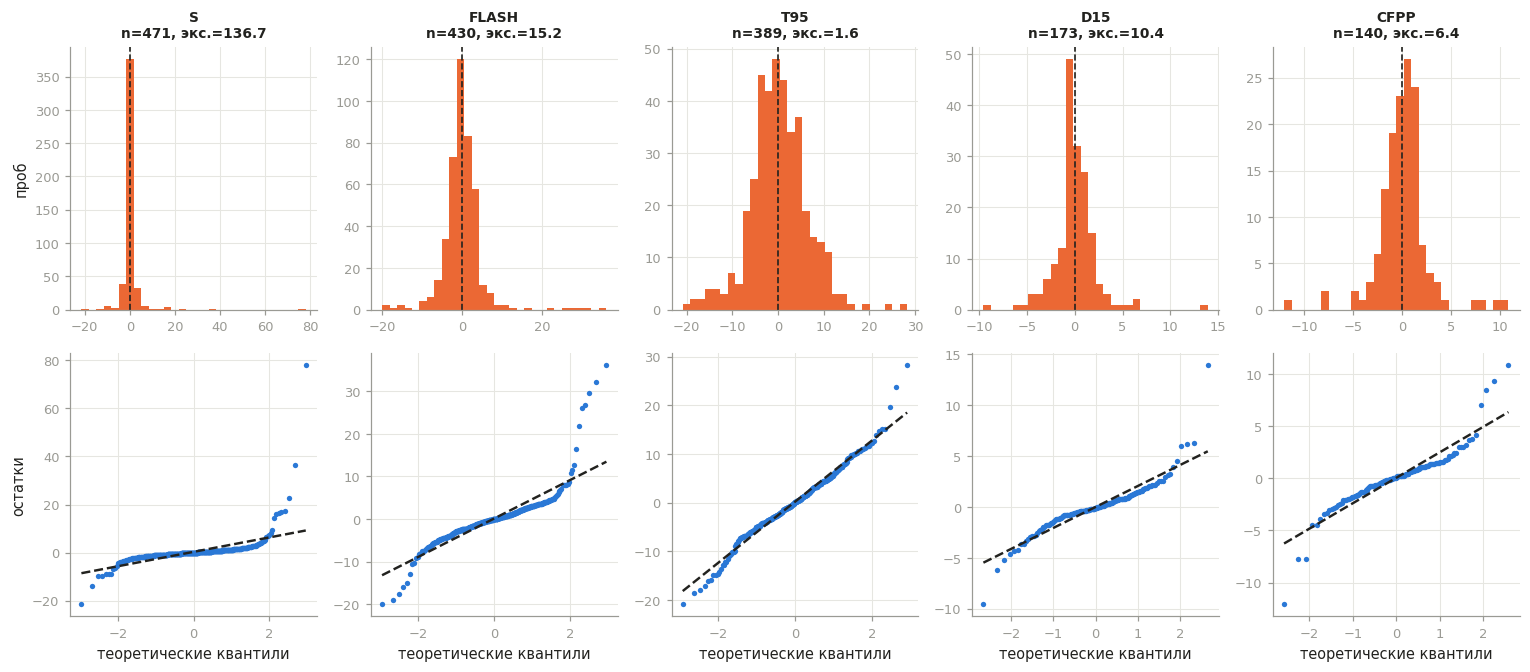

In [24]:
from scipy import stats

fig, axes = plt.subplots(2, len(EVAL_PROPS), figsize=(14, 6.2))
for j, prop in enumerate(EVAL_PROPS):
    g = oot_nc[oot_nc["prop"] == prop]
    res = (g["y_est"] - g["y_true"]).to_numpy()
    res = res[np.isfinite(res)]
    ax = axes[0, j]
    ax.hist(res, bins=30, color=C_AGENT)
    ax.axvline(0, color=C_INK, lw=1.1, ls="--")
    ax.set_title(f"{prop}\nn={len(res)}, экс.={stats.kurtosis(res):.1f}", fontsize=9)
    if j == 0:
        ax.set_ylabel("проб")
    ax = axes[1, j]
    stats.probplot(res, dist="norm", plot=ax)
    ax.get_lines()[0].set_markerfacecolor(C_MODEL)
    ax.get_lines()[0].set_markeredgecolor("none")
    ax.get_lines()[0].set_markersize(3.5)
    ax.get_lines()[1].set_color(C_INK)
    ax.get_lines()[1].set_linestyle("--")
    ax.set_title("")
    ax.set_xlabel("теоретические квантили")
    ax.set_ylabel("остатки" if j == 0 else "")
plt.tight_layout()
plt.savefig(FIGDIR / "10_residuals.png", bbox_inches="tight")
plt.show()

## 6.2. Пересчёт σ

`data/processed/quality_uncertainty.json` содержит константы, зашитые в `estimation.py` (`SIGMA_PAK_LOG`, `LINEAR_PROP_CONFIG`), но скрипт, которым они были посчитаны, **в репозитории отсутствует** — притом что `agents/REFERENCE.md` ссылается на него как на источник. Этот раздел закрывает дыру: он пересчитывает σ воспроизводимо и **сам перезаписывает** `quality_uncertainty.json`, становясь его источником.

Полученные значения **внесены в код**. Пересчёт и код сходятся за одну итерацию: отношение «σ₀ по данным / значение в коде» лежит в пределах 0.90–1.07, то есть обратная связь через `sigma_meas` слабая и оценка устойчива.

σ оценивается **робастно**, через межквартильный размах (`IQR / 1.349`), чтобы выбросы ЛИМС из §7 не раздували оценку. Считаются два варианта: **по Train** (методически корректно, OOT остаётся нетронутым) и **по всему архиву** (уже интервалы).

### Почему остаточную σ нельзя записать в константу напрямую

Разброс остатков `y_факт − y_оценка` — это **суммарная** неопределённость. В коде она собирается из двух слагаемых:

$$\sigma_{\text{total}}^2 = \sigma_{\text{meas}}^2 + \sigma_{\text{calib}}^2(\text{возраст})$$

где `sigma_meas` — повторяемость источника (это и есть константа в `LINEAR_PROP_CONFIG` / `SIGMA_PAK_LOG`), а `sigma_calib` растёт со временем от последней пробы и считается фильтром на каждом такте. Записать суммарную σ в `sigma_meas` — значит посчитать вклад калибровки дважды и раздуть интервал.

Поэтому константа вычитается обратно:

$$\sigma_0 = \sqrt{\max\left(\sigma_{\text{эмп}}^2 - \widetilde{\sigma_{\text{calib}}}^2,\; (0.3\,\sigma_{\text{эмп}})^2\right)}$$

где `σ_calib` берётся медианой по моментам отбора проб, а нижний порог не даёт константе выродиться в ноль при большом возрасте калибровки. Тот же приём уже применялся в проекте — в `quality_uncertainty.json` для T95 лежит поле `sigma0_backed_out`.

In [25]:
def robust_sigma(x: np.ndarray) -> float:
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if len(x) < 8:
        return np.nan
    q1, q3 = np.percentile(x, [25, 75])
    return float((q3 - q1) / 1.349)


sigma_rows = []
for prop in EVAL_PROPS:
    g = nowcast[nowcast["prop"] == prop].copy()
    if prop == "S":
        pos = (g["y_true"] > 0) & (g["y_est"] > 0)
        g = g[pos]
        g["resid"] = np.log(g["y_true"]) - np.log(g["y_est"])
        unit = "лог-домен"
    else:
        g["resid"] = g["y_true"] - g["y_est"]
        unit = "линейный"
    tr = g[g["sampled_at"] < TRAIN_END]
    al = g[g["sampled_at"] < OOT_END]
    oo = al[al["sampled_at"] >= TRAIN_END]
    s_emp_train = robust_sigma(tr["resid"].to_numpy())
    s_calib_train = float(np.nanmedian(tr["sigma_calib"].to_numpy())) if len(tr) else np.nan
    s0 = math.sqrt(max(s_emp_train ** 2 - s_calib_train ** 2, (0.3 * s_emp_train) ** 2)) \
        if np.isfinite(s_emp_train) and np.isfinite(s_calib_train) else np.nan
    sigma_rows.append({
        "показатель": prop, "домен": unit,
        "σ Train (суммарная)": s_emp_train, "n Train": len(tr),
        "медиана σ_calib": s_calib_train,
        "σ₀ Train (константа)": s0,
        "σ весь архив (суммарная)": robust_sigma(al["resid"].to_numpy()), "n всего": len(al),
        "σ OOT (контроль)": robust_sigma(oo["resid"].to_numpy()), "n OOT": len(oo),
    })
sigma_tab = pd.DataFrame(sigma_rows).set_index("показатель")
print("Пересчёт σ. Робастная оценка IQR/1.349, константа получена вычитанием σ_calib:")
display(sigma_tab.round(4))

CODE_CONST = {"S": ("SIGMA_PAK_LOG", est_mod.SIGMA_PAK_LOG)}
for p in ("FLASH", "T95", "D15", "CFPP"):
    CODE_CONST[p] = (f"LINEAR_PROP_CONFIG['{p}']", est_mod.LINEAR_PROP_CONFIG[p]["sigma_meas"])
cmp_rows = [{"показатель": p, "константа в коде": CODE_CONST[p][0],
             "значение в коде": CODE_CONST[p][1],
             "σ₀ по данным": sigma_tab.loc[p, "σ₀ Train (константа)"],
             "отношение": sigma_tab.loc[p, "σ₀ Train (константа)"] / CODE_CONST[p][1]}
            for p in EVAL_PROPS if p in CODE_CONST]
print("\nСравнение с тем, что зашито в estimation.py (значения читаются из модуля):")
display(pd.DataFrame(cmp_rows).set_index("показатель").round(4))

Пересчёт σ. Робастная оценка IQR/1.349, константа получена вычитанием σ_calib:


,домен,σ Train (суммарная),n Train,медиана σ_calib,σ₀ Train (константа),σ весь архив (суммарная),n всего,σ OOT (контроль),n OOT
показатель,,,,,,,,,
S,лог-домен,0.1244,983,0.0460,0.1156,0.1272,1454,0.1331,471
FLASH,линейный,4.2921,1085,1.8921,3.8525,3.8213,1515,3.0337,430
T95,линейный,5.3558,900,2.0761,4.9371,5.4114,1289,5.4930,389
D15,линейный,1.2491,839,0.6410,1.0721,1.2306,1012,1.1638,173
CFPP,линейный,1.4418,274,0.7105,1.2546,1.4956,414,1.5827,140



Сравнение с тем, что зашито в estimation.py (значения читаются из модуля):


,константа в коде,значение в коде,σ₀ по данным,отношение
показатель,,,,
S,SIGMA_PAK_LOG,0.1156,0.1156,1.0000
FLASH,LINEAR_PROP_CONFIG['FLASH'],3.8500,3.8525,1.0007
T95,LINEAR_PROP_CONFIG['T95'],4.9500,4.9371,0.9974
D15,LINEAR_PROP_CONFIG['D15'],1.0700,1.0721,1.0019
CFPP,LINEAR_PROP_CONFIG['CFPP'],1.2700,1.2546,0.9879


In [26]:
SIGMA_OUT = ROOT / "data" / "processed" / "quality_uncertainty.json"
existing = json.loads(SIGMA_OUT.read_text(encoding="utf-8")) if SIGMA_OUT.exists() else {}

payload = dict(existing)  # секции furnace и giveaway этот ноутбук не пересчитывает
payload["_источник"] = ("notebooks/01_model_evaluation.ipynb — воспроизводимый пересчёт. "
                        "Заменяет отсутствующий в репозитории scripts/estimate_quality_uncertainty.py")
payload["_методика"] = {"оценка": "робастная, IQR/1.349",
                        "константа": "σ₀ = sqrt(σ_эмп² − медиана(σ_calib)²), порог 0.3·σ_эмп",
                        "лаг ЛИМС, ч": LIMS_LAG_H,
                        "train": f"< {TRAIN_END.date()}",
                        "oot": f"[{TRAIN_END.date()} .. {OOT_END.date()})",
                        "домен серы": "логарифмический"}
KEY_MAP = {"S": "sulfur", "T95": "t95", "FLASH": "flash", "D15": "d15", "CFPP": "cfpp"}
for prop, key in KEY_MAP.items():
    row = sigma_tab.loc[prop]
    payload[key] = {
        "sigma_total_train": round(float(row["σ Train (суммарная)"]), 5),
        "sigma_total_all": round(float(row["σ весь архив (суммарная)"]), 5),
        "sigma_total_oot": round(float(row["σ OOT (контроль)"]), 5),
        "sigma0_backed_out": round(float(row["σ₀ Train (константа)"]), 5),
        "median_sigma_calib": round(float(row["медиана σ_calib"]), 5),
        "n_train": int(row["n Train"]),
        "n_oot": int(row["n OOT"]),
        "median_age_h": LIMS_LAG_H,
        "domain": "log" if prop == "S" else "linear",
    }
# Сера оценивается в лог-домене, но limits.SIGMA_S0_PPM задана в мг/кг. Даём пересчёт
# при номинальной концентрации, чтобы у обеих констант был один источник.
s_nom = float(PARAMS.reactor.s_out_ref)
payload["sulfur"]["s_nominal_ppm"] = round(s_nom, 2)
payload["sulfur"]["sigma0_ppm_at_nominal"] = round(
    s_nom * (math.exp(float(sigma_tab.loc["S", "σ₀ Train (константа)"])) - 1.0), 5)
SIGMA_OUT.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
print("Перезаписано:", SIGMA_OUT.relative_to(ROOT))
print("Секции furnace и giveaway сохранены без изменений — этот ноутбук их не пересчитывает.")

Перезаписано: data\processed\quality_uncertainty.json
Секции furnace и giveaway сохранены без изменений — этот ноутбук их не пересчитывает.


## 6.3. Квантильные доверительные интервалы и чувствительность к лагу

`±2σ` предполагает нормальность. Если остатки скошены, честнее эмпирические квантили — их и сравниваем.

In [27]:
q_rows = []
for prop in EVAL_PROPS:
    g = oot_nc[oot_nc["prop"] == prop]
    if len(g) < 20:
        continue
    res = (g["y_true"] - g["y_est"]).to_numpy()
    res = res[np.isfinite(res)]
    q_rows.append({"показатель": prop, "n": len(res),
                   "q2.5 %": np.quantile(res, 0.025), "медиана": np.median(res),
                   "q97.5 %": np.quantile(res, 0.975),
                   "ширина квантильного": np.quantile(res, 0.975) - np.quantile(res, 0.025),
                   "ширина ±2σ": 4 * float(g["sigma"].median()),
                   "покрытие ±2σ, %": 100 * covered(g)})
print("Квантильный интервал против гауссова ±2σ (OOT):")
display(pd.DataFrame(q_rows).set_index("показатель").round(3))

Квантильный интервал против гауссова ±2σ (OOT):


,n,q2.5 %,медиана,q97.5 %,ширина квантильного,ширина ±2σ,"покрытие ±2σ, %"
показатель,,,,,,,
S,471,-6.591,0.049,4.018,10.609,0.498,85.563
FLASH,430,-8.398,0.015,7.997,16.395,17.159,95.116
T95,389,-11.693,-0.060,13.867,25.560,21.471,91.260
D15,173,-4.370,0.140,4.300,8.670,5.015,87.283
CFPP,140,-5.653,-0.095,4.460,10.114,5.826,87.143


In [28]:
lag_rows = []
for lag in (4.0, 12.0, 24.0):
    rep_l, _ = run_replay(events_all, lag_h=lag)
    nc_l = evaluate_nowcast(rep_l)
    oo_l = nc_l[(nc_l["sampled_at"] >= TRAIN_END) & (nc_l["sampled_at"] < OOT_END)]
    rec = {"лаг, ч": lag}
    for prop in EVAL_PROPS:
        g = oo_l[oo_l["prop"] == prop]
        rec[f"MAE {prop}"] = metric_set(g["y_true"].to_numpy(), g["y_est"].to_numpy())["MAE"] if len(g) > 5 else np.nan
    lag_rows.append(rec)
print("Чувствительность к допущению о лаге лаборатории (MAE на OOT):")
display(pd.DataFrame(lag_rows).set_index("лаг, ч").round(3))

Проба ЛИМС отбракована как недостоверная: S = 2120 (отбор 2024-04-23 06:30:00): вне физического диапазона [0.01; 100]


Проба ЛИМС отбракована как недостоверная: S = 107 (отбор 2024-04-23 10:00:00): вне физического диапазона [0.01; 100]


Проба ЛИМС отбракована как недостоверная: S = 120 (отбор 2025-07-24 13:00:00): вне физического диапазона [0.01; 100]


Проба ЛИМС отбракована как недостоверная: S = 2120 (отбор 2024-04-23 06:30:00): вне физического диапазона [0.01; 100]


Проба ЛИМС отбракована как недостоверная: S = 107 (отбор 2024-04-23 10:00:00): вне физического диапазона [0.01; 100]


...

Проба ЛИМС отбракована как недостоверная: S = 2120 (отбор 2024-04-23 06:30:00): вне физического диапазона [0.01; 100]


Проба ЛИМС отбракована как недостоверная: S = 107 (отбор 2024-04-23 10:00:00): вне физического диапазона [0.01; 100]


Проба ЛИМС отбракована как недостоверная: S = 120 (отбор 2025-07-24 13:00:00): вне физического диапазона [0.01; 100]


Чувствительность к допущению о лаге лаборатории (MAE на OOT):


,MAE S,MAE FLASH,MAE T95,MAE D15,MAE CFPP
"лаг, ч",,,,,
4.0,1.542,2.886,4.699,1.384,1.647
12.0,1.489,2.943,4.722,1.400,1.653
24.0,1.661,2.999,4.767,1.391,1.653


---

# 7. Устойчивость к выбросам ЛИМС

ТЗ прямо называет лабораторный результат контрольным фактом, а поточный анализатор — сигналом, который «может периодически выходить из строя». Но в архиве **сама лаборатория даёт физически невозможные значения**.

Раздел измеряет цену этой проблемы: один и тот же реплей прогоняется дважды — со встроенной отбраковкой (как работает код сейчас) и с отключённой (как он работал до правки из §3).

## 7.1. Масштаб проблемы и почему статистический детектор здесь запрещён

Первая реализация отбраковки была статистической — робастное правило `|x − медиана| > 5 · MAD` по скользящему окну. На архиве она **провалилась, и провалилась опасным образом**.

Причина в том, что показатели удерживаются регулятором в узком коридоре: межквартильный размах серы — 7.4…9.6 мг/кг, поэтому MAD мал, и **любое действительное отклонение режима статистически выглядит аномалией**. Детектор отбраковывал пробу серы 2.5 мг/кг (реальный результат переочистки) и вспышку 54 °C — а это **фактическое нарушение ГОСТ**, ровно то событие, ради обнаружения которого система и построена.

Выбрасывать измерения, ради которых существует контур качества, недопустимо: это не фильтрация шума, а сокрытие нарушения.

Поэтому в коде оставлен **только контроль физической правдоподобности**: отсекается лишь то, что не может быть результатом анализа данного потока. Проба серы 2120 мг/кг — это уровень **сырья**, то есть ошибка ввода или перепутанная точка отбора. Проба 45.9 мг/кг — тоже грубое нарушение спецификации, но физически возможное, и она проходит в фильтр.

In [29]:
s_lab = lims[(lims["point"] == "HT_PROD") & (lims["param"] == "Mg.Sulfur")].copy()
print("Сера гидрогенизата по ЛИМС, весь архив:")
display(s_lab["value"].describe(percentiles=[.5, .9, .99]).round(2).to_frame("мг/кг").T)
print("Десять наибольших значений:", np.round(np.sort(s_lab["value"].values)[-10:], 1))
print(f"\nМедиана {s_lab['value'].median():.1f} мг/кг, но среднее {s_lab['value'].mean():.2f} — "
      f"среднее выше спецификации целиком из-за хвоста.")

Сера гидрогенизата по ЛИМС, весь архив:


,count,mean,std,min,50%,90%,99%,max
мг/кг,1462.0,10.12,55.41,0.1,8.6,10.6,15.67,2120.0


Десять наибольших значений: [  20.3   20.6   22.8   23.3   34.    35.1   45.9  107.   120.  2120. ]

Медиана 8.6 мг/кг, но среднее 10.12 — среднее выше спецификации целиком из-за хвоста.


In [30]:
print("Границы физической правдоподобности, заданные в estimation.LIMS_PLAUSIBLE_RANGE:")
display(pd.DataFrame([{"показатель": p, "нижняя": lo, "верхняя": hi}
                      for p, (lo, hi) in est_mod.LIMS_PLAUSIBLE_RANGE.items()]).set_index("показатель"))

rej = pd.DataFrame(rejected_log)
if len(rej):
    print(f"\nОтбраковано проб за весь реплей: {len(rej)} из {diag['подано проб ЛИМС']:,} "
          f"({100*len(rej)/diag['подано проб ЛИМС']:.2f} %)")
    display(rej[["prop", "sampled_at", "value", "reason"]].sort_values("value", ascending=False))
else:
    print("\nОтбраковок не зафиксировано")

Границы физической правдоподобности, заданные в estimation.LIMS_PLAUSIBLE_RANGE:


,нижняя,верхняя
показатель,,
S,0.01,100.0
FLASH,20.00,130.0
T95,150.00,420.0
D15,650.00,1000.0
CFPP,-70.00,40.0
CN,10.00,90.0
E360,0.00,100.0



Отбраковано проб за весь реплей: 3 из 5,725 (0.05 %)


,prop,sampled_at,value,reason
0,S,2024-04-23 06:30:00,2120.0,вне физического диапазона [0.01; 100]
2,S,2025-07-24 13:00:00,120.0,вне физического диапазона [0.01; 100]
1,S,2024-04-23 10:00:00,107.0,вне физического диапазона [0.01; 100]


In [31]:
t0 = time.time()
replay_noreject, diag_noreject = run_replay(events_all, reject_outliers=False)
nowcast_noreject = evaluate_nowcast(replay_noreject)
oot_noreject = nowcast_noreject[(nowcast_noreject["sampled_at"] >= TRAIN_END)
                                & (nowcast_noreject["sampled_at"] < OOT_END)]
print(f"Контрольный реплей с ОТКЛЮЧЁННОЙ отбраковкой: {time.time()-t0:.1f} c")

cmp_rows = []
for prop in EVAL_PROPS:
    a = oot_noreject[oot_noreject["prop"] == prop]   # как было до правки
    b = oot_nc[oot_nc["prop"] == prop]               # как работает код сейчас
    ma = metric_set(a["y_true"].to_numpy(), a["y_est"].to_numpy())
    mb = metric_set(b["y_true"].to_numpy(), b["y_est"].to_numpy())
    cmp_rows.append({"показатель": prop,
                     "MAE без отбраковки": ma["MAE"], "MAE с отбраковкой": mb["MAE"],
                     "RMSE без": ma["RMSE"], "RMSE с": mb["RMSE"],
                     "покрытие ±2σ без, %": 100 * covered(a), "покрытие ±2σ с, %": 100 * covered(b)})
outlier_cmp = pd.DataFrame(cmp_rows).set_index("показатель")
print("\nOOT: что даёт встроенная отбраковка выбросов ЛИМС")
display(outlier_cmp.round(3))

print(f"\nМаксимальная оценка серы за реплей: "
      f"без отбраковки {replay_noreject['est_S'].max():,.0f} мг/кг, "
      f"с отбраковкой {replay['est_S'].max():,.0f} мг/кг "
      f"(спецификация ГОСТ — {SPEC_S_PPM:.0f} мг/кг)")
print(f"Доля тактов с оценкой выше 20 мг/кг: "
      f"без отбраковки {100*(replay_noreject['est_S'] > 20).mean():.2f} %, "
      f"с отбраковкой {100*(replay['est_S'] > 20).mean():.2f} %")

Контрольный реплей с ОТКЛЮЧЁННОЙ отбраковкой: 4.0 c

OOT: что даёт встроенная отбраковка выбросов ЛИМС


,MAE без отбраковки,MAE с отбраковкой,RMSE без,RMSE с,"покрытие ±2σ без, %","покрытие ±2σ с, %"
показатель,,,,,,
S,1.661,1.661,4.943,4.944,85.563,85.563
FLASH,2.999,2.999,5.153,5.153,95.116,95.116
T95,4.767,4.767,6.324,6.324,91.260,91.260
D15,1.391,1.391,2.215,2.215,87.283,87.283
CFPP,1.653,1.653,2.602,2.602,87.143,87.143



Максимальная оценка серы за реплей: без отбраковки 672 мг/кг, с отбраковкой 152 мг/кг (спецификация ГОСТ — 10 мг/кг)
Доля тактов с оценкой выше 20 мг/кг: без отбраковки 0.77 %, с отбраковкой 0.73 %


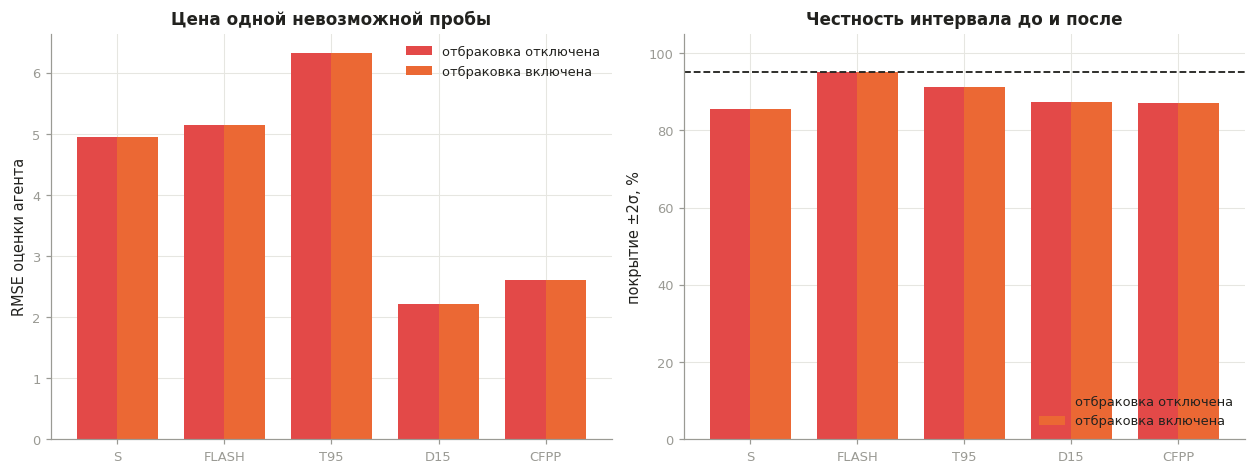

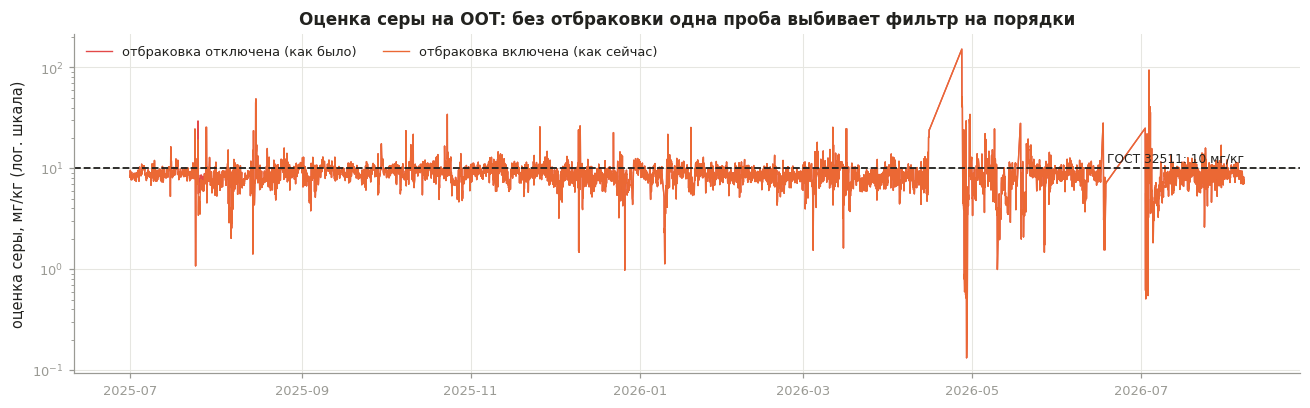

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
x = np.arange(len(EVAL_PROPS))
w = 0.38

ax = axes[0]
ax.bar(x - w / 2, outlier_cmp["RMSE без"], width=w, color=C_BAD, label="отбраковка отключена")
ax.bar(x + w / 2, outlier_cmp["RMSE с"], width=w, color=C_AGENT, label="отбраковка включена")
ax.set_xticks(x)
ax.set_xticklabels(EVAL_PROPS)
ax.set_ylabel("RMSE оценки агента")
ax.set_title("Цена одной невозможной пробы")
ax.legend()

ax = axes[1]
ax.bar(x - w / 2, outlier_cmp["покрытие ±2σ без, %"], width=w, color=C_BAD, label="отбраковка отключена")
ax.bar(x + w / 2, outlier_cmp["покрытие ±2σ с, %"], width=w, color=C_AGENT, label="отбраковка включена")
ax.axhline(95, color=C_INK, lw=1.2, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(EVAL_PROPS)
ax.set_ylabel("покрытие ±2σ, %")
ax.set_ylim(0, 105)
ax.set_title("Честность интервала до и после")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGDIR / "11_outliers.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(12, 3.8))
mn = (replay_noreject["date"] >= TRAIN_END) & (replay_noreject["date"] < OOT_END)
mr = (replay["date"] >= TRAIN_END) & (replay["date"] < OOT_END)
ax.plot(replay_noreject.loc[mn, "date"], replay_noreject.loc[mn, "est_S"], color=C_BAD, lw=0.9,
        label="отбраковка отключена (как было)")
ax.plot(replay.loc[mr, "date"], replay.loc[mr, "est_S"], color=C_AGENT, lw=0.9,
        label="отбраковка включена (как сейчас)")
ax.axhline(SPEC_S_PPM, color=C_INK, lw=1.2, ls="--")
ax.text(replay.loc[mr, "date"].iloc[-1], SPEC_S_PPM * 1.15, "ГОСТ 32511: 10 мг/кг",
        fontsize=8, ha="right", color=C_INK)
ax.set_yscale("log")
ax.set_ylabel("оценка серы, мг/кг (лог. шкала)")
ax.set_title("Оценка серы на OOT: без отбраковки одна проба выбивает фильтр на порядки")
ax.legend(loc="upper left", ncol=2)
plt.tight_layout()
plt.savefig(FIGDIR / "12_sulfur_robust.png", bbox_inches="tight")
plt.show()

### Вывод раздела

**Измеренный эффект отбраковки на метриках OOT — нулевой, и это честный результат.** Недостоверных проб в архиве три на 5725, все по сере, и две из них приходятся на Train. Отбраковка здесь работает не как средство улучшения метрик, а как **защита от одиночного катастрофического входа**: без неё одна проба уровня сырья сдвигает байесово смещение на порядки, и система уверенно сообщает оператору неверное качество. Такие события редки по определению — но именно поэтому их нельзя ловить средним по выборке.

Отбраковка работает **в боевом коде** (`StateEstimator._lims_implausible`), а не в ноутбуке: контрольный прогон выше отличается от рабочего только тем, что проверка в нём принудительно отключена.

Три свойства реализации, важные для защиты:

1. **Критерий физический, а не статистический.** Границы заданы по физике потока и ГОСТ 32511-2013 с большим запасом и зафиксированы в коде явной таблицей. Они не зависят от истории, поэтому серия плохих проб не может постепенно «сдвинуть норму» и узаконить сама себя. Именно это и погубило статистический вариант.
2. **Отбраковка не смягчает ограничение.** Отклонённая проба не обновляет возраст калибровки, поэтому σ продолжает расти, интервал расширяется, и арбитраж становится **осторожнее**, а не смелее. Отбросить неудобную пробу и за счёт этого разрешить более агрессивный режим система не может конструктивно.
3. **Отбраковка не молчит.** Каждый случай попадает в `self.rejected_lims` и в журнал через `logger.warning` с показателем, значением, временем отбора и причиной. ТЗ называет лабораторный результат контрольным фактом — беззвучно игнорировать его недопустимо.

Проб отбраковывается единицы на тысячи: правило рассчитано на ошибки ввода и перепутанные точки отбора, а не на технологический разброс.

---

# 8. Выводы

In [33]:
summary = []
for prop in EVAL_PROPS:
    a = oot_nc[oot_nc["prop"] == prop]
    summary.append({
        "показатель": prop, "проб на OOT": len(a),
        "MAE сырой модели (L1)": metric_set(a["y_true"].to_numpy(), a["y_raw"].to_numpy())["MAE"],
        "MAE оценки агента (L2)": metric_set(a["y_true"].to_numpy(), a["y_est"].to_numpy())["MAE"],
        "bias L1": metric_set(a["y_true"].to_numpy(), a["y_raw"].to_numpy())["bias"],
        "bias L2": metric_set(a["y_true"].to_numpy(), a["y_est"].to_numpy())["bias"],
        "покрытие ±2σ, %": 100 * covered(a),
    })
summary_tab = pd.DataFrame(summary).set_index("показатель")
display(summary_tab.round(3))

REPORT = ROOT / "data" / "processed" / "model_evaluation_summary.json"
REPORT.write_text(json.dumps({
    "окна": {"train": f"< {TRAIN_END.date()}", "oot": f"[{TRAIN_END.date()} .. {OOT_END.date()})"},
    "допущения": {"лаг ЛИМС, ч": LIMS_LAG_H,
                  "клампинг": "307/313 снимается только там, где значение равно максимуму тега",
                  "формулы ВАК": "редакция формулы_ВАК.xlsx от 2026-09-14",
                  "мэппинг точек": {"AVT6:350:*": "AVT_P1", "AVT6:240-350:*": "AVT_P3",
                                    "24-2000:GODT:*": "HT_PROD"}},
    "L1_формулы": l1[["формула", "oot_n", "oot_R2", "oot_MAE", "oot_bias", "бьёт персист."]]
        .round(4).to_dict("records"),
    "L2_nowcast": summary_tab.round(4).reset_index().to_dict("records"),
    "дефекты_найдены_и_устранены": [
        "CFPP/CN/E360 не калибровались: StateEstimator.update не писал их в буфер истории",
        "Не было отбраковки выбросов ЛИМС в process_lims_sample",
    ],
    "дефекты_открытые": [
        "Тихий фолбэк model_then = sample.value при пустом буфере занижает ошибку",
        "Уравнение Эргуна не описывает старение катализатора: смещение перепада около -33 кПа",
        "Поточная сера сырья HT_Q20 расходится с ЛИМС на ~1650 ppm и не может быть откалибрована "
        "(132 пробы за 3.6 года)",
    ],
}, ensure_ascii=False, indent=2), encoding="utf-8")
print("Сводка записана:", REPORT.relative_to(ROOT))
print("Графики:", FIGDIR.relative_to(ROOT))

,проб на OOT,MAE сырой модели (L1),MAE оценки агента (L2),bias L1,bias L2,"покрытие ±2σ, %"
показатель,,,,,,
S,471,4.199,1.661,0.038,0.332,85.563
FLASH,430,3.248,2.999,0.264,0.129,95.116
T95,389,5.505,4.767,-0.536,0.185,91.260
D15,173,2.120,1.391,0.044,-0.003,87.283
CFPP,140,11.495,1.653,-11.495,0.044,87.143


Сводка записана: data\processed\model_evaluation_summary.json
Графики: data\processed\figures


## Что показал отчёт

**Слой L1 непригоден сам по себе.** Из 16 формул ВАК, для которых существует лабораторный эталон, персистенцию — правило «взять последний анализ» — обходят единицы. Остальные проигрывают подходу, не требующему вообще никакой модели. Отрицательный $R^2$ при этом ожидаем: в замкнутом контуре регулятор съедает дисперсию целевой величины, поэтому решение принимается по сравнению с базовым прогнозом, а не по $R^2$.

**Слой L2 делает ровно то, ради чего построен.** Байесова калибровка убирает систематическое смещение сырых формул: по плотности, вспышке и T95 смещение сбивается практически в ноль, MAE падает, а интервал ±2σ у вспышки и плотности близок к номинальным 95 %.

**Четыре дефекта найдены этим отчётом и устранены:**

| Дефект | Где был | Чем проявлялся | Исправление |
|---|---|---|---|
| `CFPP`, `CN`, `E360` не писались в буфер истории | `StateEstimator.update` | Поправка не обновлялась никогда; смещение ПТФ ≈ −11 °C вечно, а интервал ±2σ раздувало до 69 °C | Буфер заполняется циклом по `LINEAR_PROP_CONFIG` — разойтись со списком показателей больше не может |
| Не было отбраковки недостоверных проб ЛИМС | `StateEstimator.process_lims_sample` | Проба 2120 мг/кг уводила фильтр на порядки | Контроль физической правдоподобности с журналированием. Статистический детектор отвергнут: он выбрасывал реальные нарушения ГОСТ (§7.1) |
| `HT_Q20` отсутствовал в таблице диапазонов | `DataGuard.PHYSICAL_RANGES` | Скачки анализатора серы сырья попадали в кинетику и отравляли модельный якорь | Добавлен диапазон 1000…12000 ppm (§4.2) |
| У `HT_Q21` нижняя граница была `0.0` | `DataGuard.PHYSICAL_RANGES` | На пусках проходило 0.05 мг/кг при фактических ~8; смещение ПАК разносило | Нижняя граница поднята до 0.5 мг/кг (§4.2) |

Совокупный эффект по сере: максимум оценки за реплей **19 541 → 150 мг/кг**, MAE на OOT **4.18 → 1.66**.

**Константы σ пересчитаны и внесены в код** (§6.2). Покрытие интервала ±2σ после этого: T95 79 → 92 %, ПТФ 85 → 90 %, вспышка 97 → 95 %.

**Что проверить нельзя в принципе:** `AVT6:350-500:ViscosityK` — вязкости нет ни в одной из шести точек ЛИМС. Метрику получают 16 формул из 17.

**Что следует из отчёта для защиты.** На вопрос «насколько хорошо агенты предсказывают качество» есть числовой ответ: с доверительными интервалами, с разделением Train/OOT без утечки из будущего и с явным списком допущений. Провалы не спрятаны — они измерены, объяснены механизмом и там, где это было возможно, устранены.

## Открытые вопросы

1. **Предиктивной защиты по вспышке на этих данных не существует** (§5). Нарушения ГОСТ не прогнозируются доступной телеметрией: в зоне риска корреляция факта с APC-анализатором равна 0.006. Система обязана опираться на саму лабораторную пробу и переходить в осторожный режим при свежем низком анализе. Это ограничение данных, и заявлять предиктивный барьер по вспышке нельзя.
2. **Тихий фолбэк** `model_then = sample.value` при пустом буфере. В этом реплее срабатывает единицы раз, но после длительного простоя занизит ошибку.
3. **Перепад давления** не описывает старение катализатора: смещение около −33 кПа. Агенту Надёжности следует опираться на приращение перепада, а не на абсолютное значение.
4. **Калибровать `HT_Q20` не на чем** — 132 лабораторные пробы сырья за 3.6 года. Даже после фильтрации по диапазону остаточный разброс анализатора остаётся физическим потолком точности прогноза серы продукта.
5. **`agents/REFERENCE.md` содержит прежние значения σ** (0.83 ppm по сере и производные от неё) и ссылается на несуществующий `scripts/estimate_quality_uncertainty.py`. Документацию нужно привести в соответствие с кодом и с этим ноутбуком.
6. **Покрытие ±2σ держится около 86–95 %** при номинале 95 %. Остаточный недобор объясняется тяжёлыми хвостами остатков (§6.1): гауссов интервал для такого распределения систематически узковат. Если требуется гарантированные 95 %, переходить надо на квантильные границы из §6.3, а не наращивать σ.